<a href="https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/filing-trends/filing-trends-tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEC EDGAR Filing Trends & Patterns from 1994 to 2022

In this tutorial, we'll analyze all EDGAR filings spanning from 1994 to 2022 to uncover patterns, trends, and insights across sectors, IPOs, form types, SEC offices and more.

Key areas we'll delve into include:
- **Filing Volume Dynamics**: Explore how filing volumes have shifted across sectors and years, painting a picture of the economic landscape.
- **IPO Trends**: Using S-1 filings, we'll uncover insights into the initial public offering (IPO) patterns across sectors, revealing sectors that have seen surges in new public companies.
- **M&A Activity**: Mergers and acquisitions are pivotal moments in a company's journey. We'll analyze the ebbs and flows in M&A activities over the years.
- **Delistings Analysis**: Through 25-NSE filings, we'll examine the trends in company delistings, providing insights into sectors that might be experiencing turbulence or consolidations.
- **Material Events with 8-Ks**: Dive deep into 8-K filings to understand significant corporate events across sectors, from mergers and leadership changes to financial disclosures.

To bring these insights to life, we'll leverage visualization techniques such as bar charts, box plots, and heatmaps. Here's a snapshot of the key insights we're about to uncover.

**Key Insights**:

1. **EDGAR Filing Volume**: 2021 experienced the highest EDGAR filing volume ever recorded since the introduction of EDGAR in 1994, with over 800,000 filings. 2022 followed closely, registering the second-highest annual volume.
  
2. **Dominance of Specific Form Types**: Just 2% of EDGAR form types, equivalent to 20 distinct forms, accounted for 80% of all 2022 filings. Thus, understanding these 20 form types effectively unlocks 80% of information for that year.

3. **Popular Form Types of 2022**: The leading ten EDGAR form types in 2022 were: Form 4 (representing 29% of all filings), 8-K (11%), 424B2 (9%), followed by NPORT-P, D, 13F-HR, 6-K, FWP and 10-Q.

4. **Trends in Form Types**:
   - A noticeable surge was observed in 424B2 filings from 2017 onward.
   - The number of amended filings has consistently risen since 1994, hitting a record of 60,000 amended filings in 2022.
   - Form D/A, constituting 34% of amended filings, has seen a steady increase since its 2009 introduction, peaking at over 20,000 in 2022. Together, Form D/A and Form SC 13G/A comprised 64% of the top 20 amended filings in 2022.

5. **Monthly Filing Patterns**: February recorded the highest filing volume consistently between 2004 and 2022. In contrast, September had the lowest, followed by October and July.

6. **Filing Frequency**: In 2022, 63% (100,474) of all EDGAR filers (158,517) submitted between one to two filings.

7. **Prominent Filers**: The top five entities with the most EDGAR filings in 2022 were all banks, led by JPMORGAN CHASE, filing more than 18,000 filings that year.

8. **Sectoral Analysis**: The Financial Services and Healthcare sectors generated 47% of 2022's filings. The former sector's filing volume doubled since 2009, whereas the tech sector's volume declined since its 2007 peak.

9. **SEC Oversight**: Among the 12 SEC Offices, the Office of Finance supervised 31% of 2022 filings. The Office of Manufacturing, ranking second, managed only 10%.

10. **Asset-backed Securities**: ABS filings peaked in 2006, plummeted by 2009, and have been on an upward trajectory since, surpassing their pre-financial crisis peak in 2022.

11. **SIC Classification Analysis**: NATIONAL COMMERCIAL BANKS (SIC 6021) filings have consistently risen since 1994, with a rapid growth from 2016 and a peak in 2022, representing 20% of all filings that year. SECURITY BROKERS, DEALERS & FLOTATION COMPANIES (SIC 6211) was the second most voluminous filer in 2022, with 55,000 filings, accounting for 15% of all filings.

12. **M&A and IPO Trends**: M&A activity, as indicated by S-4 and S-4/A filings, peaked between 2010-2013 and has been declining since. IPOs, represented by S-1 filings, reached an all-time high in 2021, with the Industrials and Healthcare sectors leading the charge.

12. **Delistings**: 2021 marked the record year for delistings with 2,026 25-NSE filings, closely followed by 2022 with 1,970 cases and 2007 with 1,944.

13. **Late Filing Notices**: NT 10-X filings seem to act as early indicators of financial crises, as evidenced by spikes before major market downturns.

14. **Sector-specific Form Trends**: Only the Healthcare sector saw a consistent rise in Form 4 filings since 2012. Healthcare's annual 8-K filings have increased since 2012, while other sectors have seen a decline since their 2005 peak.

## Dataset Overview

We generated two primary datasets to analyze filing volumes across dimensions like filings per form types annually from 1994 to 2022. To enhance this data, we integrated these primary datasets with two supplementary datasets, enabling us to associate a filer's CIK with additional dimensions, including sectors and SEC offices.

### Dataset Structure

The two primary and two secondary datasets are structured as follows:

- `filing_count_stats`: contains four columns `cik`, `formType`, `count`, `year`, `month`. It tracks the number of filings published on EDGAR per CIK per form type in a month and year. In other words, it indicates the type and quantity of filings an entity submitted each month/year. A single filing can be tallied more than once; for instance, if a filing includes five CIKs, it gets counted five times, once for every CIK (i.e., each individual filer).
- `volume_by_accNo`: holds four columns `formType`, `count`, `year`, `month`. It tracks all form types, and the number of filings published per form type per month and year. It indicates the quantity of filings for each form type submitted in a given month/year. Filings are counted based on their accession numbers rather than CIKs. Thus, a filing with multiple CIKs is counted only once, rather than repeatedly for each CIK.
- `filers`: contains seven columns `year`, `fiscalYearEnd`, `stateOfIncorporation`, `cik`, `companyName`, `sic`, `irsNo`, `sector`. It lists all EDGAR filers that submitted at least one filing in the specified year, alongside other associated details.
- `sic_codes` includes three columns `sic_code`, `office`, `industry_title` and maps SIC codes to their respective industry titles and SEC Offices overseeing them.

### Data Sources

The datasets, namely `filing_count_stats` and `volume_by_accNo`, were constructed using the [Query API](https://sec-api.io/docs/query-api). We employed a combination of the [Mapping API](https://sec-api.io/docs/mapping-api) and Query API to create the `filers` dataset. The `sic_codes` dataset was derived from the [SEC's mapping between SIC codes and their respective SEC Offices](https://www.sec.gov/corpfin/division-of-corporation-finance-standard-industrial-classification-sic-code-list).


### Important Considerations

- EDGAR filers are identified by their CIK, while EDGAR filings are recognized by their accession number.
- All CIKs are normalized by removing leading zeros; for instance, "0000872243" is transformed to "872243".
- The CIK aids in appending SIC code, SEC Office, and sector data to the `filing_count_stats` dataset.
- The `filedAt` column signifies the `Accepted` timestamp of the filing as reported on the EDGAR system, and it assists in determining the associated `year` and `month`.

### Analysis Workflow

The methodology for preparing data for our analysis generally adheres to the steps outlined below:

1. Choose the dimension(s) of interest, such as "across sectors".
2. Group the dataset temporally (by years or months) and by the chosen dimension (like sectors).
3. Quantify a target variable, for instance, the annual number of filings per sector.
4. Construct a pivot table, setting the year as the index and the selected dimension (e.g., sector) as columns.
5. Refine the pivot table through cleaning, filtering, and sorting actions, possibly omitting certain years like 1994-1996 to eliminate outliers.
6. Visualize the data using line charts, stacked bar charts, and box plots.

The dimensions of interest include:

- Specific form types such as 10-K, 10-Q, etc.
- Form type categories, for instance, all registration statements like S-1, S-4, F-1, N-1, etc.
- Sectors
- SEC Offices
- SIC Codes
- Timeframes: years and months
- Combinations of the aforementioned, like form types analyzed by year and sector.

## Getting Started

Let's import the relevant packages and helper functions, and load the two primary datasets: `filing_count_stats` and `volume_by_accNo`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import modules.helpers as helpers
# force reloading of modules.helpers
import importlib
importlib.reload(helpers)

plt.rcParams.update({'font.size': 8})

In [ ]:
filing_count_stats = helpers.get_volume_by_cik()

In [ ]:
filing_count_stats.head()

,cik,formType,count,year,month
0,100240,424B2,1,1994,01
1,100240,424B3,1,1994,01
2,100240,8-K,1,1994,01
3,100712,SC 13G,1,1994,01
4,100826,424B5,1,1994,01


In [ ]:
volume_by_accNo = helpers.get_volume_by_accessionNo()

In [ ]:
volume_by_accNo.sort_values(by=['year', 'month']).head()

,formType,year,month,count
1611,10-12B/A,1994,1,1
2566,10-C,1994,1,11
3011,10-K,1994,1,29
3359,10-K/A,1994,1,18
4191,10-Q,1994,1,106


---

## Plotting Functions Used in This Tutorial

Throughout this tutorial, we leverage two primary plotting functions to simplify our data visualization process.

**`plot_2_figs(pivot_table)`**: This function simultaneously generates a line graph and a stacked bar chart within a single figure. The line graph is displayed on the left, while the stacked bar chart appears on the right.
- **X-axis**: Represents the time values, typically spanning from the years 1994 to 2022.
- **Y-axis**: Denotes the count values.
- **Legend**: A single, unified legend is utilized for both plots.
   
**`plot_box_plot(pivot_table)`**: This function produces a box plot based on the provided pivot table.
   
**Input Requirements for Both Functions**:
Both plotting functions expect a pivot table in the form of a dataframe. The requirements for the dataframe are:
   - **Index**: Represents the time scale, which can be years, months, or any other time measurement.
   - **Columns**: Correspond to any particular dimension, such as sectors.
   - **Values**: Should be numerical counts.

In [ ]:
def plot_2_figs(data, title, figsize=(10, 4)):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

  # create color map for factors
  factors = data.columns
  # viridis, plasma, magma, inferno, cividis, tab20
  colors = plt.cm.tab20(np.linspace(0, 1, len(factors)))
  colormap = dict(zip(factors, colors))

  sorted_data_1 = data.T.sort_values(2022, ascending=False).T
  sorted_data_2 = data.T.sort_values(2022, ascending=True).T

  sorted_data_1.plot(ax=ax1, color=[colormap[sector] for sector in sorted_data_1.columns])
  ax1.set_title(""), ax1.set_ylabel("Filing Volume"), ax1.set_xlabel("Year"),
  ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
  ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  ax1.grid(), ax1.set_axisbelow(True)
  ax1.set_xticks(range(1994, 2023)), ax1.set_xticklabels(range(1994, 2023), rotation=90, ha='center')
  ax1.legend().set_visible(False)

  sorted_data_2.plot(kind='bar', stacked=True, ax=ax2, color=[colormap[sector] for sector in sorted_data_2.columns])
  ax2.set_title(""), ax2.set_ylabel(""), ax2.set_xlabel("Year"), ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90, ha='center')
  ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
  handles, labels = ax2.get_legend_handles_labels()
  ax2.legend(reversed(handles), reversed(labels), bbox_to_anchor=(1.05, 1), loc='upper left')
  ax2.grid(), ax2.set_axisbelow(True)

  fig.suptitle(title, fontsize=12)
  plt.tight_layout()
  plt.show()

In [ ]:
def plot_box_plot(data: pd.DataFrame, title, x_label="", y_label="", figsize=(5, 4)):
  data.boxplot(figsize=figsize)
  plt.title(title), plt.ylabel(y_label), plt.xlabel(x_label), plt.tight_layout()
  ax = plt.gca()
  ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
  max_xticklabels = max([len(label.get_text()) for label in ax.get_xticklabels()])
  rotation = 90 if max_xticklabels > 3 else 0
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')
  plt.show()

Let's demonstrate the functions with some sample data.

In [ ]:
np.random.seed(42)
years = list(range(1994, 2023))
sectors = ["Technology", "Finance", "Health", "Energy"]

sample_1 = pd.DataFrame({
    "Year": np.tile(years, len(sectors)),
    "Sector": np.repeat(sectors, len(years)),
    "Filing Volume": np.random.randint(500, 5000, len(years) * len(sectors))
})

pivot_data_sample_1 = sample_1.pivot(index='Year', columns='Sector', values='Filing Volume')

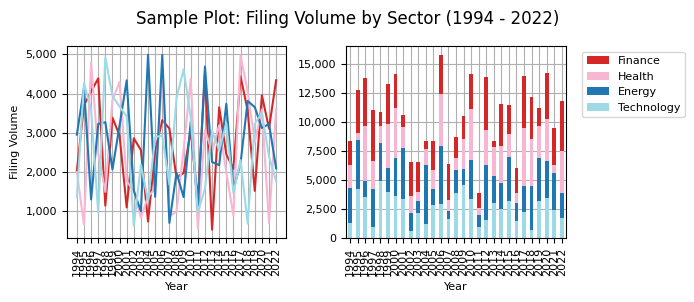

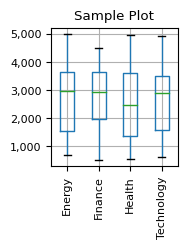

In [ ]:
plot_2_figs(pivot_data_sample_1, "Sample Plot: Filing Volume by Sector (1994 - 2022)", figsize=(7,3))
plot_box_plot(pivot_data_sample_1, "Sample Plot", figsize=(2,2))

---

## Annual Filing Volume by Form Type

To understand the yearly distribution of filings, we'll consolidate our data to display the aggregate count of filings for each form type per year. We begin by grouping the `volume_by_accNo` dataframe based on two columns: `formType` and `year`. For each combination of `formType` and `year`, we sum up the values in the `count` column across all months of the specific year. This results in a DataFrame that shows the total number of filings for each form type in each year. The result is then stored in the `type_year_stats` DataFrame.

In [ ]:
type_year_stats = pd.DataFrame(volume_by_accNo.groupby(['formType', 'year'])['count'].sum())

Next, the `type_year_stats` DataFrame is pivoted using the `pivot_table` method. The `formType` is set as the index, and the `year` values are set as the columns. This effectively reshapes the data such that each row corresponds to a specific `formType` and each column corresponds to a specific `year`. The values in the pivoted table represent the total number of filings for a given `formType` in a specific year.

In [ ]:
type_year_stats_piv = type_year_stats.pivot_table(index='formType', columns='year', values='count')

Some combinations of `formType` and `year` might not have any filings, resulting in NaN (Not a Number) values in the pivoted table. This line fills those NaN values with zeros using the `fillna` method. Additionally, the `astype(int)` method is used to ensure all the numbers in the DataFrame are integers.
Then, we re-arranges the columns of the `type_year_stats_piv` DataFrame in reverse order, starting with the year 2022 instead of 1994. The `iloc` method is used to select all rows and columns in reverse order (from the latest year to the earliest year).
Finally, the rows of the `type_year_stats_piv` DataFrame are sorted based on the values in the 2022 column. This results in a DataFrame where the form types with the highest filing volumes in 2022 appear at the top, allowing for better visualization and reading the figure legend later on.

In [ ]:
type_year_stats_piv = type_year_stats_piv.fillna(0).astype(int)
type_year_stats_piv = type_year_stats_piv.iloc[:, ::-1]
type_year_stats_piv = type_year_stats_piv.sort_values(2022, ascending=False)

In [ ]:
print('Number of EDGAR Filings per Form Type per Year (1994 - 2022)')
type_year_stats_piv

Number of EDGAR Filings per Form Type per Year (1994 - 2022)


year,2022,2021,2020,2019,2018,2017,2016,2015,2014,2013,...,2003,2002,2001,2000,1999,1998,1997,1996,1995,1994
formType,,,,,,,,,,,,,,,,,,,,,
4,182342,194456,180689,175434,180457,180800,182191,191904,193757,193172,...,160028,29298,11304,11756,10310,9467,6595,2253,0,0
8-K,68214,72895,70558,64664,66434,68772,70483,74391,74899,74153,...,65427,43121,33543,28440,26836,27072,23565,15381,6245,3484
424B2,59582,60345,44968,34295,31987,27144,18451,15494,13829,12713,...,1568,1557,1517,1153,1050,1655,1835,1630,1518,1133
NPORT-P,49843,48590,47500,8998,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
D,41672,42506,28153,27502,27272,24589,23097,23030,22194,19841,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
U-33-S/A,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
U-3A-2,0,0,0,0,0,0,0,0,0,0,...,86,82,76,90,99,101,86,75,72,53
U-3A-2/A,0,0,0,0,0,0,0,0,0,0,...,23,23,10,6,11,11,12,6,7,21


We are now ready to plot the number of EDGAR filings by form type per year, from 1994 to 2022. We use pandas' builtin `.plot` function to visualize the filing volumes as stacked bar chart. Executing the plot snippet takes around 1 to 2 minutes.

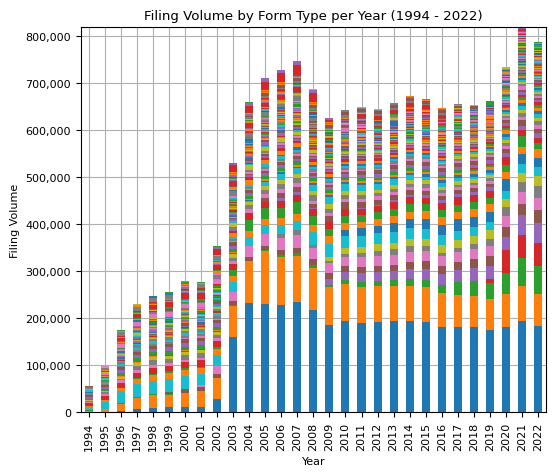

In [ ]:
type_year_stats_piv.iloc[:, ::-1].T.plot(kind='bar', stacked=True, figsize=(6, 5))
plt.title("Filing Volume by Form Type per Year (1994 - 2022)"), plt.ylabel("Filing Volume"), plt.xlabel("Year")
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.get_legend().remove(), ax.grid(), ax.set_axisbelow(True)
plt.show()

The next line sums up all EDGAR filings per year.

In [ ]:
pd.DataFrame(type_year_stats_piv.sum(axis=0), columns=['volume']).head(10).T

year,2022,2021,2020,2019,2018,2017,2016,2015,2014,2013
volume,786768,817572,733003,660181,652410,655758,645884,666349,671145,657310


Let's identify the top 20 EDGAR form types from 2022 and then explore their filing trends since 1994.

In [ ]:
top_20_types = list(type_year_stats_piv.sort_values(2022, ascending=False).head(20).index)
top_20_types_piv = type_year_stats_piv.loc[top_20_types]

print('Top 20 most commonly filed from types in 2022')
print(top_20_types_piv[2022][:20].index.to_list())

Top 20 most commonly filed from types in 2022
['4', '8-K', '424B2', 'NPORT-P', 'D', '13F-HR', '6-K', 'FWP', 'D/A', '10-Q', '497K', 'SC 13G/A', '3', '497', '10-D', 'CORRESP', '424B3', 'SC 13G', '10-K', 'LETTER']


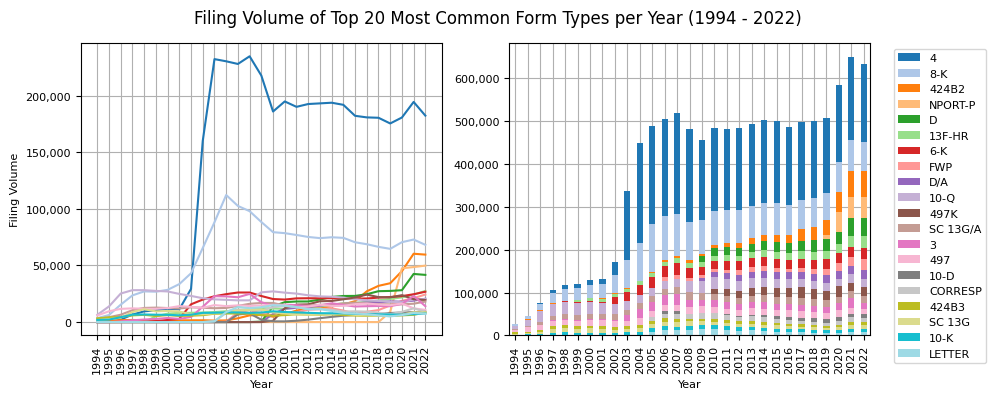

In [ ]:
plot_2_figs(top_20_types_piv.iloc[:, ::-1].T, "Filing Volume of Top 20 Most Common Form Types per Year (1994 - 2022)")

In [ ]:
print('2022 Filing Volume of Top 20 Most Common Form Types')
print("-"*60)
size_top_20_volume = top_20_types_piv[2022].sum() / type_year_stats_piv[2022].sum()
size_top_20_form_types = top_20_types_piv[2022].count() / type_year_stats_piv[2022].count()
print("Total filing volume: {:,}".format(type_year_stats_piv[2022].sum()))
print("Top 20 form types volume: {:,}".format(top_20_types_piv[2022].sum()))
print("Volume of top 20 to total volume: {:.1%}".format(size_top_20_volume))
print("-"*60)
print("All form types in 2022: {}".format(type_year_stats_piv[2022].count()))
print("Top 20 form types to all form types: {:.1%}".format(size_top_20_form_types))

2022 Filing Volume of Top 20 Most Common Form Types
------------------------------------------------------------
Total filing volume: 786,768
Top 20 form types volume: 633,272
Volume of top 20 to total volume: 80.5%
------------------------------------------------------------
All form types in 2022: 893
Top 20 form types to all form types: 2.2%


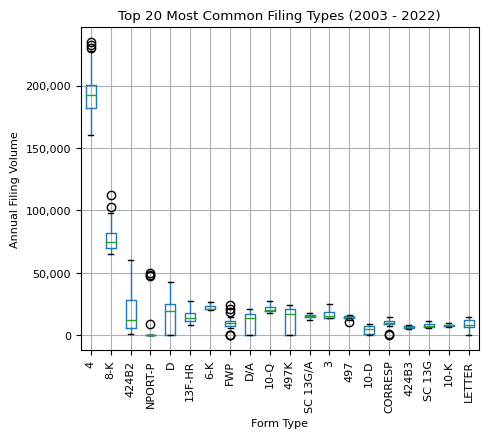

In [ ]:
plot_box_plot(top_20_types_piv[range(2003, 2023)].T,
              title="Top 20 Most Common Filing Types (2003 - 2022)",
              x_label="Form Type",
              y_label="Annual Filing Volume")

In [ ]:
top_20_types_piv.T.describe().astype(int)

formType,4,8-K,424B2,NPORT-P,D,13F-HR,6-K,FWP,D/A,10-Q,497K,SC 13G/A,3,497,10-D,CORRESP,424B3,SC 13G,10-K,LETTER
count,29,29,29,29,29,29,29,29,29,29,29,29,29,29,29,29,29,29,29,29
mean,138033,61307,13305,5342,11998,11467,16174,6879,7529,21788,8783,13568,12262,13469,3067,6504,6103,7486,7033,6140
std,89920,29024,17304,15065,13856,7423,9929,7032,8278,4730,10102,3713,7732,2263,3459,5343,1083,2311,1754,5437
min,0,3484,1050,0,0,0,0,0,0,6402,0,2499,0,5782,0,0,3321,1757,1853,0
25%,11756,33543,1557,0,0,8114,2805,0,0,19252,0,12466,3598,12133,0,0,5614,6456,6514,0
50%,182191,70483,5914,0,379,11674,20923,7333,61,21636,0,14564,14034,14080,1166,9016,6123,7469,7259,7027
75%,193757,76922,15494,0,23030,16561,22776,10589,15949,25210,19446,16130,16026,14983,6707,10823,6603,9093,8178,11273
max,234772,112225,60345,49843,42506,27500,26805,24327,20609,28178,24252,18092,24846,16402,9035,14251,8498,11329,9496,14912


In [ ]:
top_20_types_2022 = type_year_stats_piv[2022].sort_values(ascending=False).to_frame().head(20)
top_20_types_2022['pct'] = (top_20_types_2022[2022] / top_20_types_2022[2022].sum()) * 100
top_20_types_2022['pct'] = top_20_types_2022['pct'].round(1)
top_20_types_2022

,2022,pct
formType,,
4,182342,28.8
8-K,68214,10.8
424B2,59582,9.4
NPORT-P,49843,7.9
D,41672,6.6
13F-HR,27500,4.3
6-K,26805,4.2
FWP,24327,3.8
D/A,20609,3.3


**Observations**:

- 2021 experienced the highest EDGAR filing volume ever recorded, with over 800,000 filings. 2022 followed closely, registering the second-highest annual volume.
- In 2022, the top 20 most common EDGAR form types accounted for 80% of all filings, even though they represented just 2% of the total 893 EDGAR form types available.
- Conversely, the remaining 98% of form types, which translates to 873 distinct forms, contributed to only 20% of the total filings in 2022.
- This stark contrast demonstrates a significant information asymmetry: a small fraction of form types dominate the vast majority of the filing volume.
- The leading ten EDGAR form types in 2022 were: 4 (29%), 8-K (11%), 424B2 (9%), followed by 'NPORT-P', 'D', '13F-HR', '6-K', 'FWP', 'D/A', and '10-Q'.
- A narrow candle in the box plot for filings like 6-K indicates a stable filing volume over the past 20 years, with minimal annual fluctuations.

### Amended Filings

Occasionally companies need to make corrections or provide updated information to previously submitted filings. These corrected or updated submissions are known as **amended filings**.

For instance, the Form S-1 is a document that companies must submit when they intend to go public through an Initial Public Offering (IPO). It serves as a preliminary prospectus, commonly referred to as a "red herring" due to the bold red disclaimer on its cover. This disclaimer indicates that the information within the prospectus is not final and may undergo changes. The S-1 offers potential investors a detailed view of the company's business operations, financial status, management, and both the risks and benefits of the offered securities. However, it often lacks finalized details such as the exact number of shares to be issued or the price range for the offering. During the IPO process, situations may arise where the company needs to update material information, rectify inaccuracies, or provide additional context based on feedback from investors and regulators. To address these changes, the company submits an amended registration statement, the Form S-1/A. Like its predecessor, the S-1/A might also be presented as a "red herring" with the characteristic disclaimer, signifying that the information is closer to being finalized but is still subject to change.

Another example represents 10-K filings (annual reports) that publicly traded companies must submit to the SEC. It provides an in-depth look at a company's operational and financial performance for the past fiscal year. Sometimes, during the SEC's review of these filings, the staff might identify areas of concern, seek clarifications, or request additional disclosures. This process often results in a series of correspondence between the SEC staff and the company. The content of these correspondences can often serve as triggers for companies to amend their initial filings. If the SEC staff's review highlights material discrepancies, omissions, or misrepresentations in the original 10-K, the company may be prompted (or even required) to submit an amended 10-K, known as Form 10-K/A.

Amended filings are identified by the suffix **'/A'** added to the original form type. So, an amended S-1 filing would appear as "S-1/A".


In [ ]:
amended_types_piv = type_year_stats_piv[type_year_stats_piv.index.str.contains('/A')]
top_20_types_amended = list(amended_types_piv.sort_values(2022, ascending=False).head(20).index)
top_20_types_amended_piv = amended_types_piv.loc[top_20_types_amended]
top_20_types_amended_piv

year,2022,2021,2020,2019,2018,2017,2016,2015,2014,2013,...,2003,2002,2001,2000,1999,1998,1997,1996,1995,1994
formType,,,,,,,,,,,,,,,,,,,,,
D/A,20609,18931,17964,18295,17422,17346,16686,15949,15794,14536,...,0,0,0,0,0,0,0,0,0,0
SC 13G/A,18092,16219,15652,15625,15807,16396,17143,16417,15588,15192,...,12589,13022,12008,12400,12757,12483,10461,6482,4318,2499
SC 13D/A,4017,3890,4141,3806,4193,4148,4271,4186,4002,4249,...,5119,5048,4899,5134,5146,5461,5418,3783,1911,807
4/A,3456,3672,3695,3748,3673,3891,4389,5026,4835,4798,...,7392,1334,489,365,247,276,123,78,0,0
S-1/A,1848,3538,1732,1198,1574,1613,1626,2124,2770,2539,...,641,820,869,2873,3061,2132,2490,2204,128,81
8-K/A,1802,1855,1719,1712,1792,2398,1850,2252,2590,2771,...,3590,2985,2713,2876,2831,3233,2824,2136,791,308
C/A,1612,1834,1503,785,718,494,173,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13F-HR/A,1265,1146,974,1102,1041,1026,1022,1278,949,1296,...,1056,1075,958,768,475,0,0,0,0,0
MA-I/A,1169,1173,1101,1429,1397,2083,1366,1367,2,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print("Annual filing volume of top 20 amended filing types:")
pd.DataFrame(top_20_types_amended_piv.sum(), columns=['volume']).T

Annual filing volume of top 20 amended filing types:


year,2022,2021,2020,2019,2018,2017,2016,2015,2014,2013,...,2003,2002,2001,2000,1999,1998,1997,1996,1995,1994
volume,60315,59847,54781,52821,52837,54459,53757,54140,52763,52087,...,37030,30082,27234,29392,30220,29548,27072,19370,10156,5039


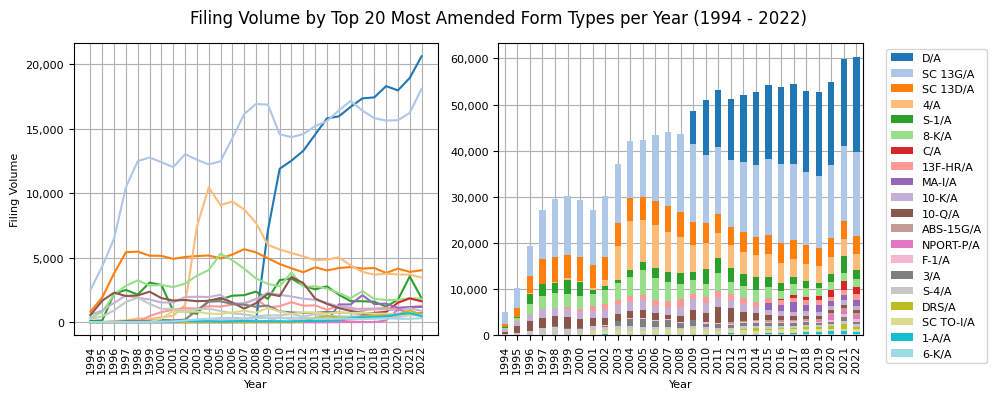

In [ ]:
plot_2_figs(top_20_types_amended_piv.iloc[:, ::-1].T, "Filing Volume by Top 20 Most Amended Form Types per Year (1994 - 2022)")

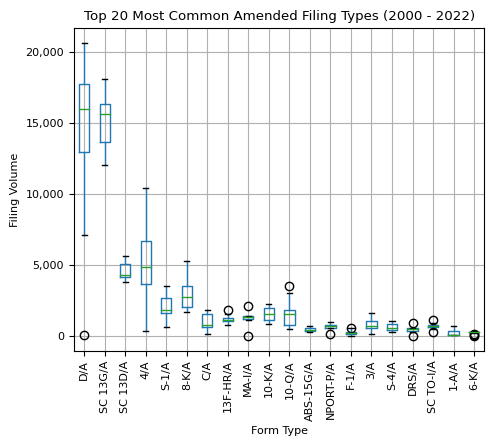

In [ ]:
plot_box_plot(top_20_types_amended_piv.replace(0, np.nan)[range(2000, 2023)].T,
              "Top 20 Most Common Amended Filing Types (2000 - 2022)",
              "Form Type",
              "Filing Volume")

In [ ]:
top_20_types_per_sector_2022 = pd.DataFrame(top_20_types_amended_piv.T.loc[2022]).sort_values(by=2022, ascending=False)
top_20_types_per_sector_2022['pct'] = top_20_types_per_sector_2022[2022] / top_20_types_per_sector_2022[2022].sum() * 100
top_20_types_per_sector_2022 = top_20_types_per_sector_2022.round(1)
top_20_types_per_sector_2022[:10]

,2022,pct
formType,,
D/A,20609,34.2
SC 13G/A,18092,30.0
SC 13D/A,4017,6.7
4/A,3456,5.7
S-1/A,1848,3.1
8-K/A,1802,3.0
C/A,1612,2.7
13F-HR/A,1265,2.1
MA-I/A,1169,1.9


**Observations**:

- The number of filing amendments has consistently increased since 1994, hitting an all-time high of over 60,000 filings in 2022.
- In 2022, Form D/A accounted for 34% of these top 20 amended filings, while SC 13G/A contributed another 30%. Combined, they represented 64% of the total volume, both hitting record highs that year.
- Since its debut in 2009, Form D's annual amendments have steadily climbed, reaching over 20,000 in 2022—up from 12,000 in 2010.
- Form SC 13D/A is the third most prevalent amendment type. Its annual volume has been consistent, hovering between 4,500 and 5,000 filings yearly since 1997.
- Amended Form 4 filings experienced a notable rise from 2002 to 2004 but have consistently decreased since, reaching a historical low in 2022.
- 10-K/A filings show a consistent distribution without any outliers, suggesting steady amendment volumes over the years, even during economic downturns.
- Most filings exhibit low skewness, indicating a regular update frequency over the years.

**Form D & SC 13G Excursion**

- Form D informs about a private sale of securities to raise capital privately, often from a limited group of investors. It involves a simplified reporting process compared to an IPO.
- SC 13G filings are submitted by institutional investors, like mutual funds and pension funds, to disclose their ownership in a publicly traded company.



---

## Monthly Filing Volume Trends

Next up, the visualization of monthly filing volume over the last three decades. It helps establish a baseline and observe how specific years deviate from this norm, allowing for the identification of patterns or anomalies.

**Seasonality vs. Anomalies**: Certain months may consistently register higher or lower filing numbers due to elements like fiscal year-ends or regulatory deadlines. Distinguishing between regular seasonal variations and unique patterns is key to spotting anomalies and discovering trends.

**Variability and Predictability**: The interquartile range and potential outliers offer insights into the consistency of filings for each month over the years. For instance, a month showcasing a vast range indicates its filing volume may be harder to predict.

In [ ]:
stats_year_month = volume_by_accNo.sort_values(by=['year', 'month'], ascending=True) \
                                  .drop(columns='formType') \
                                  .groupby(['year', 'month']) \
                                  .sum() \
                                  .reset_index()

In [ ]:
stats_year_month_piv = stats_year_month.pivot(index='year', columns='month', values='count')
stats_year_month_piv.fillna(0, inplace=True)
stats_year_month_piv = stats_year_month_piv.astype(int)

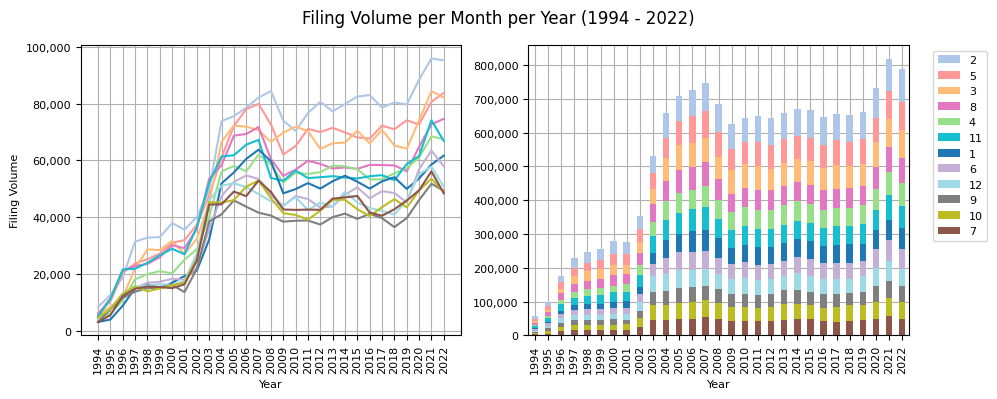

In [ ]:
plot_2_figs(stats_year_month_piv, "Filing Volume per Month per Year (1994 - 2022)")

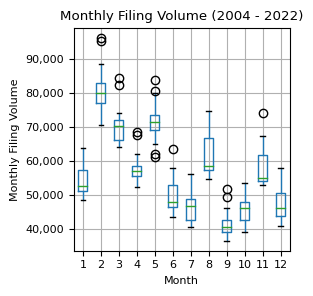

In [ ]:
plot_box_plot(stats_year_month_piv.loc[2004:],
              "Monthly Filing Volume (2004 - 2022)",
              "Month",
              "Monthly Filing Volume", figsize=(3, 3))

**Observations**:

- Between 2004 and 2022, February consistently registered the highest monthly filing volume.
- A declining trend in volume is observed from February through the end of each year.
- September sees the sparsest filing activity, with October and July being the next quietest months.
- Notable upticks in filing volume are evident in February, May, August, and November, likely driven by the due dates for 10-Q and 10-K filings.
- The monthly filing volume displays a predictable zigzag pattern: an initial surge from January to February, a subsequent dip from February to April, and this cycle continues throughout the year.

---

## Filing Volume per EDGAR Filer

Next, we'll analyze the annual submission frequency for each EDGAR filer from 1994 to 2022 using the `filing_count_stats` dataset. We'll categorize the 2022 data to understand the distribution, such as the count of filers who submitted 1-2 filings, 3-4 filings, and so forth. Additionally, we'll identify the top contributors for 2022 and their respective submission counts.

In [ ]:
filing_counts_year = filing_count_stats.groupby(['year', 'cik', 'formType']).sum().reset_index()
filing_counts_year.drop(columns=['month'], inplace=True)
filing_counts_year['year'] = filing_counts_year['year'].astype(int)

In [ ]:
print("Number of filings per form type filed by CIK 1000045 in 2022:")
filing_counts_year[(filing_counts_year['year'] == 2022) & (filing_counts_year['cik'] == '1000045')].sort_values(by='count', ascending=False)

Number of filings per form type filed by CIK 1000045 in 2022:


,year,cik,formType,count
7213867,2022,1000045,8-K,18
7213866,2022,1000045,4,13
7213864,2022,1000045,10-Q,3
7213872,2022,1000045,SC 13G,2
7213863,2022,1000045,10-K,1
7213865,2022,1000045,3,1
7213868,2022,1000045,8-K/A,1
7213869,2022,1000045,DEF 14A,1
7213870,2022,1000045,DEFR14A,1
7213871,2022,1000045,SC 13D/A,1


In [ ]:
filings_per_cik_year = filing_counts_year.groupby(['year', 'cik']).sum().reset_index()
filings_per_cik_year.drop(columns=['formType'], inplace=True)

In [ ]:
print("Number of all filings filed by CIK 1000045 in 2022:")
filings_per_cik_year[(filings_per_cik_year['year'] == 2022) & (filings_per_cik_year['cik'] == '1000045')]

Number of all filings filed by CIK 1000045 in 2022:


,year,cik,count
2898221,2022,1000045,43


In [ ]:
filings_per_cik_year_piv = filings_per_cik_year.pivot(index='cik', columns='year', values='count')
filings_per_cik_year_piv.fillna(0, inplace=True)
filings_per_cik_year_piv = filings_per_cik_year_piv.astype(int)
filings_per_cik_year_piv['mean'] = filings_per_cik_year_piv.mean(axis=1)
filings_per_cik_year_piv['median'] = filings_per_cik_year_piv.median(axis=1)

In [ ]:
filer_2022_view = filings_per_cik_year_piv[2022]>0
filings_per_cik_2022 = filings_per_cik_year_piv[filer_2022_view][2022]

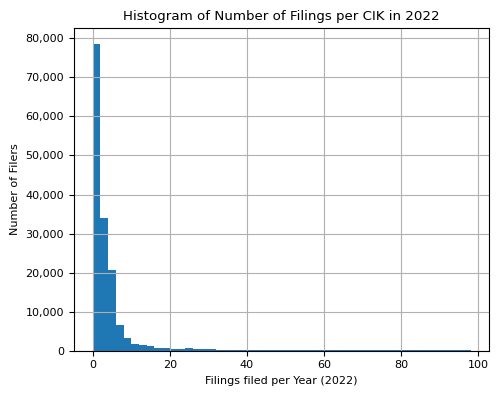

In [ ]:
filings_per_cik_2022.hist(bins=range(0, 100, 2), figsize=(5, 4))
plt.title("Histogram of Number of Filings per CIK in 2022")
plt.ylabel("Number of Filers"), plt.xlabel("Filings filed per Year (2022)"), plt.tight_layout()
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.show()

In [ ]:
print("Number of filers per range of filings submitted in 2022:")
pd.DataFrame(filings_per_cik_2022.value_counts(bins=range(0, 100, 2)).head(10))

Number of filers per range of filings submitted in 2022:


,count
2022,
"(-0.001, 2.0]",100474
"(2.0, 4.0]",26442
"(4.0, 6.0]",10429
"(6.0, 8.0]",4451
"(8.0, 10.0]",2248
"(10.0, 12.0]",1412
"(12.0, 14.0]",1374
"(14.0, 16.0]",990
"(24.0, 26.0]",762


In [ ]:
print("Number of filers in 2022: {:,}".format(len(filings_per_cik_2022.index)))

Number of filers in 2022: 158,517


In [ ]:
print("Top 5 CIKs that submitted the most filings in 2022:")
filings_per_cik_2022.sort_values(ascending=False).head(5).to_frame()

Top 5 CIKs that submitted the most filings in 2022:


,2022
cik,
19617,18288
1665650,17865
895421,14605
1666268,14081
831001,13831


**Observations**:

- Out of the 158,517 filers in 2022, 100,474 (or 63%) submitted between 1 to 2 filings.
- JPMORGAN CHASE (CIK: 19617) led the pack in 2022 with over 18,000 filings.
- The five most prolific filers of 2022 were all banking institutions: JPMORGAN CHASE (CIK: 19617), JPMorgan Chase Financial (CIK: 1665650), MORGAN STANLEY (CIK: 895421), Morgan Stanley Finance (CIK: 1666268), and CITIGROUP (CIK: 831001).

---

## Filing Volume per Sector

In this section, we'll examine the distribution of filings by sector from 1994 to 2022. To achieve this, we'll extend the `filing_count_stats` dataset by incorporating sector details. This involves merging the `filers` dataset with the `filing_count_stats` dataframe using the `cik` and `year` columns. Once we've constructed a pivot table with years and sectors as dimensions and yearly sector filing volume as values, we'll use our plotting functions for visualization.

In [ ]:
filers = helpers.get_filers()
filers.head()

/Users/jan/PycharmProjects/research/edgar-patterns/modules/helpers.py:231: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, dtype={"cik": str, "fiscalYearEnd": str, "sic": str})


,year,fiscalYearEnd,stateOfIncorporation,cik,companyName,sic,irsNo,sector,industry
0,1994,1231,LA,96035,SYSTEM FUELS INC (Filer),0000,NaN,NaN,NaN
1,1994,1130,NaN,89954,TRUST FOR SHORT TERM U S GOVERNMENT SECURITIES...,NaN,251289316,NaN,NaN
2,1994,0331,MA,901823,PUTNAM MANAGED HIGH YIELD TRUST (Filer),0000,046733967,NaN,NaN
3,1994,1231,NY,872243,EMPIRE STATE MUNICIPAL EXEMPT TRUST GUARANTEED...,0000,NaN,NaN,NaN
4,1994,1231,NY,872246,EMPIRE STATE MUNICIPAL EXEMPT TRUST GUARANTEED...,0000,NaN,NaN,NaN


In [ ]:
filing_count_stats = filing_count_stats.merge(filers[['cik', 'year', 'sector']], how='left', on=['cik', 'year'])
filing_count_stats.head(100)

,cik,formType,count,year,month,sector
0,100240,424B2,1,1994,01,NaN
1,100240,424B3,1,1994,01,NaN
2,100240,8-K,1,1994,01,NaN
3,100712,SC 13G,1,1994,01,NaN
4,100826,424B5,1,1994,01,NaN
...,...,...,...,...,...,...
95,14707,8-K,1,1994,01,Consumer Cyclical
96,14827,DEF 14A,1,1994,01,Industrials
97,14827,S-3,1,1994,01,Industrials
98,14846,DEF 14A,1,1994,01,Real Estate


In [ ]:
# add SIC code, sector, industry columns
filings_per_cik_year_meta = filings_per_cik_year.merge(filers[['year', 'cik', 'sic', 'sector', 'industry']], on=['year','cik'], how='left')
# split sic column into two columns: sic_code, sic_desc by splitting on the first space
filings_per_cik_year_meta[['sic_code', 'sic_desc']] = filings_per_cik_year_meta['sic'].str.split(' ', n=1, expand=True)
filings_per_cik_year_meta['sic_code'] = filings_per_cik_year_meta['sic_code'].str.lstrip('0')
filings_per_cik_year_meta.drop(columns=['sic'], inplace=True)
filings_per_cik_year_meta.head()

,year,cik,count,sector,industry,sic_code,sic_desc
0,1994,100030,3,Consumer Cyclical,Auto Parts,3714,Motor Vehicle Parts &amp; Accessories
1,1994,100063,2,Technology,Scientific & Technical Instruments,3823,"Industrial Instruments For Measurement, Displa..."
2,1994,100122,2,NaN,NaN,4911,Electric Services
3,1994,100166,9,Consumer Cyclical,Textile Manufacturing,2253,Knit Outerwear Mills
4,1994,100240,26,NaN,NaN,4833,Television Broadcasting Stations


In [ ]:
print(len(filings_per_cik_year), len(filings_per_cik_year_meta))

3056738 3056738


In [ ]:
filings_per_sector_year = filings_per_cik_year_meta[['year', 'sector', 'count']].groupby(['year', 'sector']).sum().reset_index()
filings_per_sector_year

,year,sector,count
0,1994,Basic Materials,1730
1,1994,Communication Services,1126
2,1994,Consumer Cyclical,2636
3,1994,Consumer Defensive,1522
4,1994,Energy,934
...,...,...,...
314,2022,Healthcare,84840
315,2022,Industrials,58828
316,2022,Real Estate,17435
317,2022,Technology,59326


In [ ]:
filings_per_sector_year_piv = filings_per_sector_year.pivot(index='year', columns='sector', values='count')
filings_per_sector_year_piv[-10:]

sector,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Utilities
year,,,,,,,,,,,
2013,24443,20280,40740,18108,27374,96301,56197,46422,20627,61212,10607
2014,24141,19455,41360,18122,29245,100807,63226,45093,20981,59384,10876
2015,22828,18488,40939,17593,26724,98417,66208,45183,20496,59703,11151
2016,21734,18409,38394,16492,25410,93656,64004,43274,20375,55140,11188
2017,22547,17892,38547,15862,25282,101651,65482,43075,20497,52350,9987
2018,20605,18446,37215,15628,23776,103849,67769,45750,19560,50485,10137
2019,19849,17170,36315,14755,21189,107134,71650,43133,18561,50539,9137
2020,20813,19056,38889,16123,19287,125586,83129,45145,19054,52912,8865
2021,20941,20358,43454,17470,18562,144650,91429,64791,20526,65057,9562


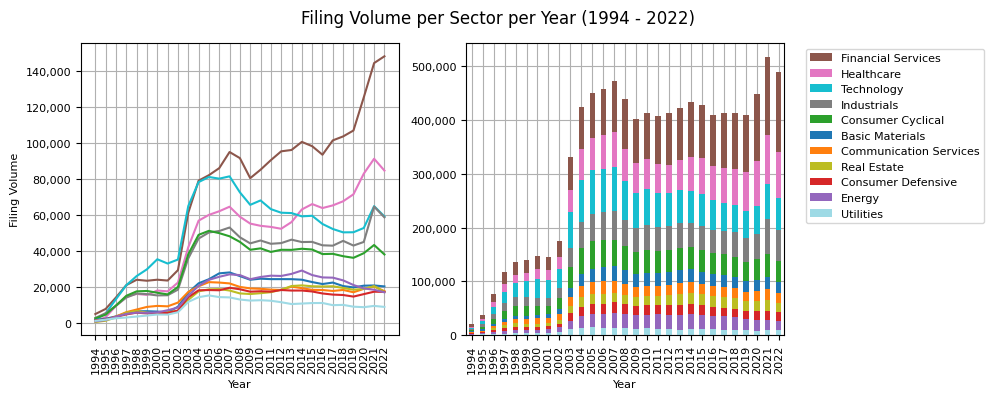

In [ ]:
plot_2_figs(filings_per_sector_year_piv, "Filing Volume per Sector per Year (1994 - 2022)")

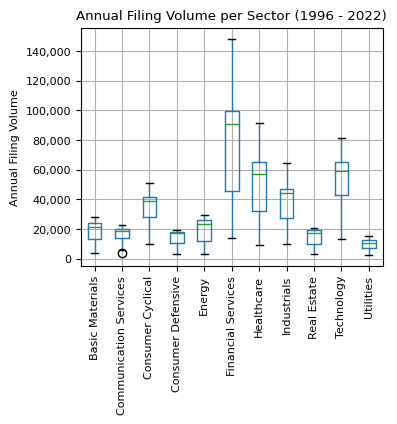

In [ ]:
plot_box_plot(filings_per_sector_year_piv.loc[1996:],
              "Annual Filing Volume per Sector (1996 - 2022)", "", "Annual Filing Volume", figsize=(4, 3))

In [ ]:
filings_per_sector_2022 = pd.DataFrame(filings_per_sector_year_piv.loc[2022]).sort_values(by=2022, ascending=False)
filings_per_sector_2022['pct'] = filings_per_sector_2022[2022] / filings_per_sector_2022[2022].sum() * 100
filings_per_sector_2022 = filings_per_sector_2022.round(1)
filings_per_sector_2022

,2022,pct
sector,,
Financial Services,148421,30.4
Healthcare,84840,17.4
Technology,59326,12.1
Industrials,58828,12.0
Consumer Cyclical,38184,7.8
Basic Materials,20413,4.2
Communication Services,17756,3.6
Real Estate,17435,3.6
Consumer Defensive,17351,3.6


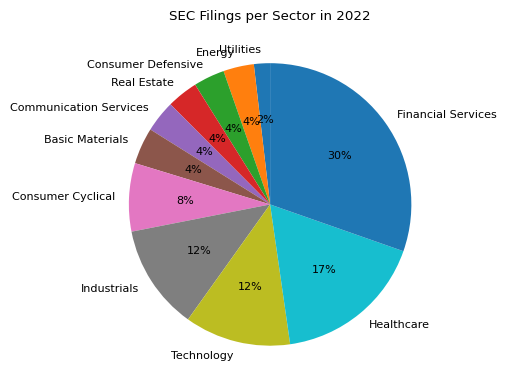

In [ ]:
filings_per_sector_year_piv.loc[2022].sort_values(ascending=True).plot(kind='pie', figsize=(5, 5), autopct='%1.0f%%', startangle=90, fontsize=8)
plt.title("SEC Filings per Sector in 2022"), plt.ylabel(""), plt.tight_layout()
plt.show()

**Observations**:

- The aggregated annual filing volume across all sectors reached its all-time high in 2021 with over 500,000 filings for the year, and exceeded the last record from 2006, just before the financial crisis.
- The Financial Services sector has dominated in terms of filing volume since 2004. Prior to this, the Technology sector led the pack.
- While the annual filing volume in the Financial Services sector has generally been on the rise, notable exceptions include the periods during the 2008/09 financial crisis and between 2014 to 2016.
- In 2022, the Financial Services sector contributed to 30% of all sector-linked filings, totaling nearly 150,000. The Healthcare sector trailed, with 85,000 filings, accounting for 17% of the year's total volume. Together, the Financial Services and Healthcare sectors constituted 47% of the entire filing volume in 2022.
- The Healthcare sector stands out as the only sector, apart from Financial Services, to display a consistent upward trajectory in filing volume. It began its ascent in 2012 and reached a record high in 2021.
- Contrarily, the filing volume across most other sectors has been waning since 2007.
- While the Technology, Industrials, and Consumer Cyclical sectors saw a modest uptick between 2020 to 2021, their volumes in 2022 were still significantly lower than their 2007 peaks.
- Sectors such as Utilities, Real Estate, Energy, Basic Materials, and Communications Services exhibit minimal fluctuations in their annual filing volumes. This stability might suggest a lower likelihood of unexpected information or surprises, potentially leading to reduced stock price volatility within these sectors.

---

## Filing Volume per SEC Office

The SEC uses SIC codes to help organize and delegate the oversight and review of company filings based on industry specialization within the Division of Corporation Finance.

The **SEC's Division of Corporation Finance** is responsible for ensuring that investors are provided with material information to make informed investment decisions, primarily through the review of documents that publicly traded companies are required to file with the SEC.

**Assignment of Review Responsibility**: Within the Division of Corporation Finance, there are multiple offices responsible for the review of filings. These offices are often organized based on industries. To determine which office reviews which company's filings, the SEC frequently uses the company's SIC code to categorize it into the appropriate industry.

The **SIC Codes** system classifies industries with a three- or four-digit code. Every publicly traded company has an associated SIC code that represents its primary business activity.

For example, a company primarily involved in the software industry has a different SIC code than a company in the pharmaceutical industry. When these companies file documents with the SEC, the filings of the software company are reviewed by an office specializing in technology companies, while the filings of the pharmaceutical company are reviewed by an office specializing in healthcare companies.

Keep in mind that not every filer has an associated SIC code, so some may not be linked to a specific SEC Office in our analysis. Additionally, a single filing can reference multiple EDGAR entities, each having distinct SIC codes. In these instances, the filing contributes to the annual volume count for each entity, influencing multiple SIC codes simultaneously.

Before diving into the analysis, we'll enhance the `filings_per_cik_year_meta` dataframe from the previous section by introducing a new `office` column. This will be achieved by merging it with the `sic_codes` dataframe.

In [ ]:
sic_codes = helpers.get_sic_codes()
sic_codes.head()

,sic_code,office,industry_title
0,100,Industrial Applications and Services,AGRICULTURAL PRODUCTION-CROPS
1,200,Industrial Applications and Services,AGRICULTURAL PROD-LIVESTOCK & ANIMAL SPECIALTIES
2,700,Industrial Applications and Services,AGRICULTURAL SERVICES
3,800,Industrial Applications and Services,FORESTRY
4,900,Industrial Applications and Services,"FISHING, HUNTING AND TRAPPING"


In [ ]:
filings_per_cik_year_meta = filings_per_cik_year_meta.merge(sic_codes[['sic_code', 'office']], how='left', on='sic_code')
filings_per_cik_year_meta.head()

,year,cik,count,sector,industry,sic_code,sic_desc,office
0,1994,100030,3,Consumer Cyclical,Auto Parts,3714,Motor Vehicle Parts &amp; Accessories,Office of Manufacturing
1,1994,100063,2,Technology,Scientific & Technical Instruments,3823,"Industrial Instruments For Measurement, Displa...",Industrial Applications and Services
2,1994,100122,2,NaN,NaN,4911,Electric Services,Office of Energy & Transportation
3,1994,100166,9,Consumer Cyclical,Textile Manufacturing,2253,Knit Outerwear Mills,Office of Manufacturing
4,1994,100240,26,NaN,NaN,4833,Television Broadcasting Stations,Office of Technology


In [ ]:
filings_per_office_year = filings_per_cik_year_meta[['year', 'office', 'count']].groupby(['year', 'office']).sum().reset_index()
filings_per_office_year

,year,office,count
0,1994,Industrial Applications and Services,2281
1,1994,Office of Energy & Transportation,6079
2,1994,Office of Finance,9432
3,1994,Office of Finance or Office of Crypto Assets,96
4,1994,Office of International Corp Fin,3
...,...,...,...
340,2022,Office of Manufacturing,62537
341,2022,Office of Real Estate & Construction,51960
342,2022,Office of Structured Finance,36211
343,2022,Office of Technology,58047


In [ ]:
filings_per_office_year_piv = filings_per_office_year.pivot(index='year', columns='office', values='count')
filings_per_office_year_piv.fillna(0, inplace=True)
filings_per_office_year_piv = filings_per_office_year_piv.astype(int)
filings_per_office_year_piv[-10:]

office,Industrial Applications and Services,Office of Crypto Assets,Office of Energy & Transportation,Office of Finance,Office of Finance or Office of Crypto Assets,Office of International Corp Fin,Office of Life Sciences,Office of Manufacturing,Office of Real Estate & Construction,Office of Structured Finance,Office of Technology,Office of Trade & Services
year,,,,,,,,,,,,
2013,43728,2563,67232,104434,4504,1105,30173,73472,41826,10577,59810,71086
2014,44928,2269,66902,107530,4491,1214,35766,69805,41053,11527,58563,70697
2015,44341,2756,62116,104487,4458,1106,37994,68416,40788,13183,57278,67424
2016,43006,2389,57984,100819,4486,1076,37422,63485,40392,13476,54459,61462
2017,41892,1777,55174,113094,2949,1291,39026,60722,40786,14452,52776,61281
2018,40130,1947,53462,119790,3360,1132,41982,59238,40296,16573,54994,57885
2019,39827,1449,49991,124669,3256,1446,45567,56446,38339,19690,52331,55110
2020,42211,1648,47604,156109,3546,1277,52325,57333,47537,29617,52426,58704
2021,44116,1159,47597,186159,4300,1175,55884,61027,73389,33252,59367,61124


In [ ]:
print("Total number of filings filed in 2022 with entities that are assigned a SIC Code:")
filings_per_office_year_piv.loc[2022].sum()

Total number of filings filed in 2022 with entities that are assigned a SIC Code:


615716

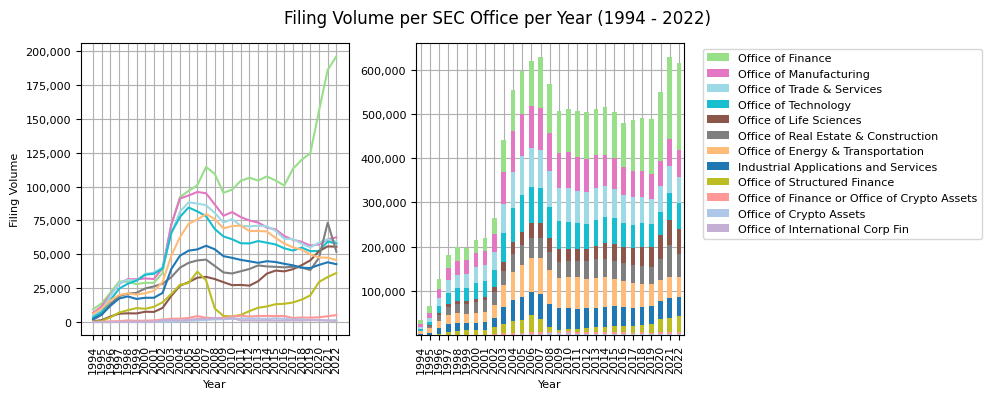

In [ ]:
plot_2_figs(filings_per_office_year_piv, "Filing Volume per SEC Office per Year (1994 - 2022)")

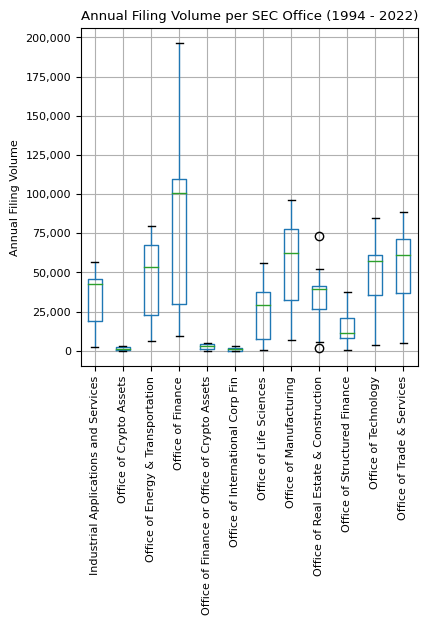

In [ ]:
plot_box_plot(filings_per_office_year_piv,
              "Annual Filing Volume per SEC Office (1994 - 2022)", "", "Annual Filing Volume")

In [ ]:
filings_per_office_2022 = pd.DataFrame(filings_per_office_year_piv.loc[2022]).sort_values(by=2022, ascending=False)
filings_per_office_2022['pct'] = filings_per_office_2022[2022] / filings_per_office_2022[2022].sum() * 100
filings_per_office_2022 = filings_per_office_2022.round(1)
print("Annual Filing Volume and Percentage Distribution per SEC Offices in 2022:")
filings_per_office_2022

Annual Filing Volume and Percentage Distribution per SEC Offices in 2022:


,2022,pct
office,,
Office of Finance,196203,31.9
Office of Manufacturing,62537,10.2
Office of Trade & Services,59321,9.6
Office of Technology,58047,9.4
Office of Life Sciences,55581,9.0
Office of Real Estate & Construction,51960,8.4
Office of Energy & Transportation,45793,7.4
Industrial Applications and Services,42733,6.9
Office of Structured Finance,36211,5.9


**Observations**:

1. The majority of SEC Offices have seen a decline in their annual filing volume since the period of 2005-2007.
2. A notable exception is the Office of Finance, which has experienced robust growth in annual filing volume since 1994. Its volume dipped only during 2007-2009 and 2014-2016. In 2022, it was responsible for nearly 200,000 filings, accounting for 32% of the total volume across all SEC Offices.
3. The Office of Structured Finance also deviates from the general trend. After peaking in 2006 with 30,000 filings, it saw a precipitous drop to under 5,000 by 2009. However, it has been on an upward trajectory since then, reaching a new record in 2022.
4. The Office of Life Sciences presents a unique trend as well. After a slight decline from 2006 to 2012, it has consistently grown year-over-year, achieving its highest filing volume in 2022.
5. The Office of Real Estate & Construction exhibited an anomaly in its filing trend. It witnessed a rapid growth from 2019 to 2021, only to experience a decline in 2022.

**Office of Structured Finance**

The Office of Structured Finance focuses on the oversight of structured finance products. In particular, the office focuses on **securitized products**, primarily asset-backed securities (ABS). ABS are securities that are collateralized by a pool of assets, such as mortgages (Mortgage-Backed Securities or MBS), auto loans, credit card receivables, student loans, and other types of financial assets. Given the complexity and diversity of structured finance products, and the role they played in the 2007-2008 financial crisis, the office's responsibilities are critical for the stability and integrity of the financial markets.

---

## Filing Volume per SIC Codes

In [ ]:
filings_per_sic_year = filings_per_cik_year_meta[['year', 'sic_code', 'count']].groupby(['year', 'sic_code']).sum().reset_index()
filings_per_sic_year

,year,sic_code,count
0,1994,,25011
1,1994,100,41
2,1994,1000,59
3,1994,1040,105
4,1994,1044,18
...,...,...,...
12591,2022,8888,611
12592,2022,8900,93
12593,2022,900,134
12594,2022,9721,30


In [ ]:
filings_per_sic_year_piv = filings_per_sic_year.pivot(index='year', columns='sic_code', values='count')
filings_per_sic_year_piv.fillna(0, inplace=True)
filings_per_sic_year_piv = filings_per_sic_year_piv.astype(int)

In [ ]:
top_20_sics_2022 = filings_per_sic_year_piv.T.sort_values(by=2022, ascending=False)[2022].head(20).index.to_list()

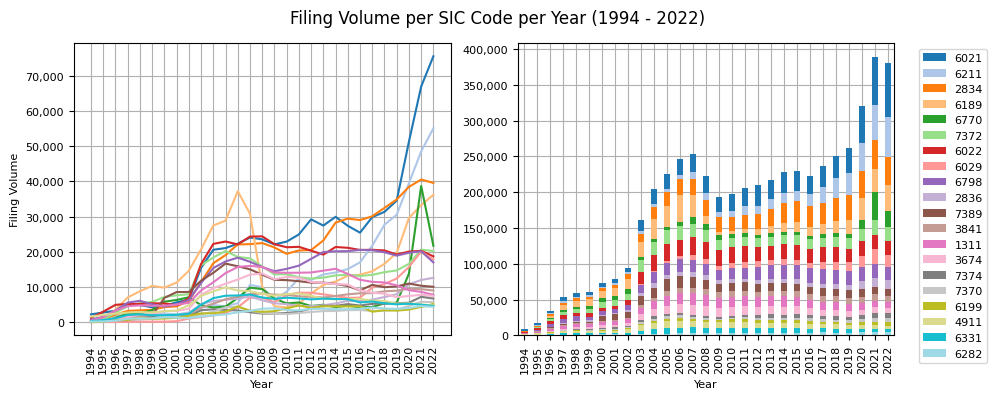

In [ ]:
plot_2_figs(filings_per_sic_year_piv[top_20_sics_2022], "Filing Volume per SIC Code per Year (1994 - 2022)")

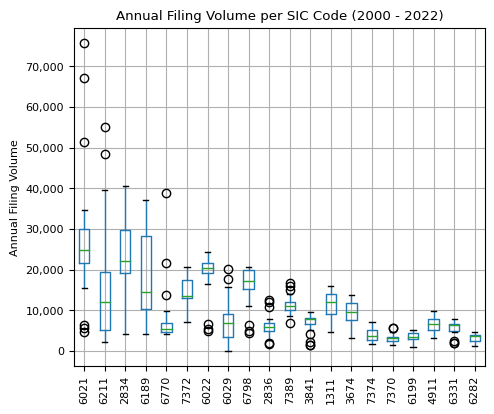

In [ ]:
plot_box_plot(filings_per_sic_year_piv.T[range(2000, 2023)].T[top_20_sics_2022],
              "Annual Filing Volume per SIC Code (2000 - 2022)", "", "Annual Filing Volume")

In [ ]:
top_20_sic_stats_2022 = pd.DataFrame(filings_per_sic_year_piv[top_20_sics_2022].T[2022])
top_20_sic_stats_2022 = top_20_sic_stats_2022.merge(sic_codes[['sic_code', 'industry_title']], how='left', on='sic_code')
top_20_sic_stats_2022['pct'] = top_20_sic_stats_2022[2022] / top_20_sic_stats_2022[2022].sum() * 100
top_20_sic_stats_2022 = top_20_sic_stats_2022.round(1)
top_20_sic_stats_2022.head(10)

,sic_code,2022,industry_title,pct
0,6021,75614,NATIONAL COMMERCIAL BANKS,19.9
1,6211,55134,"SECURITY BROKERS, DEALERS & FLOTATION COMPANIES",14.5
2,2834,39586,PHARMACEUTICAL PREPARATIONS,10.4
3,6189,36211,ASSET-BACKED SECURITIES,9.5
4,6770,21693,BLANK CHECKS,5.7
5,7372,20221,SERVICES-PREPACKAGED SOFTWARE,5.3
6,6022,18699,STATE COMMERCIAL BANKS,4.9
7,6029,17810,"COMMERCIAL BANKS, NEC",4.7
8,6798,16965,REAL ESTATE INVESTMENT TRUSTS,4.5
9,2836,12580,"BIOLOGICAL PRODUCTS, (NO DISGNOSTIC SUBSTANCES)",3.3


**Observations**:

- In 2022, the NATIONAL COMMERCIAL BANKS (SIC 6021) sector submitted the most filings. Their annual volume has been on a consistent rise since 1994, with a pronounced surge from 2016 onwards. This sector reached a peak in 2022 with over 75,000 filings, a substantial jump from 27,000 in 2016. This means that the filings from this sector alone constituted 20% of all 2022 filings.
- The second-highest filing volume in 2022 was attributed to SECURITY BROKERS, DEALERS & FLOTATION COMPANIES (SIC 6211), accounting for around 55,000 filings or 15% of the year's total.
- The PHARMACEUTICAL PREPARATIONS (SIC 2834) sector has seen a consistent growth since 2012, moving from just over 20,000 annual filings to 40,000 in 2021.
- The rise of Blank Check companies (often referred to as SPACs or shell companies) was evident in 2021, marking their highest annual filing volume for this SIC code. Starting with fewer than 8,000 filings in 2019, they soared to nearly 40,000 in 2021, before halving to around 20,000 in 2022.
- Asset-backed securities (ABS - SIC 6189) filings stood out in 2006 with 35,000 annual filings, potentially acting as an early warning sign preceding the financial crisis. This category saw the fastest growth rate from 1997 to 2006. However, post the 2006 peak, ABS filings plummeted to 5,000 in 2009 but have been on an upward trajectory since, surpassing their pre-crisis peak in 2022.

---

## IPO & Registration Statement Volumes

Registration statements filed on the EDGAR system, such as Forms S-1, S-4 and others, are used by companies and other entities to register new securities before they can be offered to the public. These forms provide detailed information about the issuer and the securities being offered. The main purpose of these registration statements is to provide potential investors with the necessary information to make informed investment decisions.

The following list represents on overview of registration statements and their purposes.

| Form Type  | Description                                                                                                                         |
|------------|-------------------------------------------------------------------------------------------------------------------------------------|
|  S-1   | This is the primary registration form for new securities and used for initial public offerings (IPOs). It provides a comprehensive overview of the company's business, financial statements, management, risks, and other relevant data. |
|  S-1MEF| Registration adding securities to prior Form S-1 registration                                                                         |
|  S-3   | Used by companies that meet specific reporting requirements, offering a "short form" registration.                                      |
|  S-4   | Used for registration of securities in merger and acquisition situations.  When one company acquires another, and as part of the deal, issues its own shares to the shareholders of the acquired company, those shares need to be registered, and the S-4 provides details about the transaction and the combined entity.                                                              |
|  S-8   | Used to register securities to be offered to employees through employee benefit plans.                                                  |
|  S-11  | Used to register securities of real estate investment trusts (REITs).                                                                  |
|  F-1   | Used by foreign companies to register securities they intend to list on American exchanges.                                             |
|  F-3   | Similar to the S-3 but for foreign issuers that meet the reporting requirements.                                                       |
|  F-4   | Equivalent to the S-4 but for foreign issuers.                                                                                        |
|  F-6   | Used to register American Depositary Receipts (ADRs) issued by a depositary against the deposit of the securities of a foreign issuer.  |
|  SB-1  | Used by small business issuers to register securities for an aggregate offering price of up to $10 million.                            |
|  SB-2  | Used by small business issuers, allowing them to register securities without a limit on the aggregate offering price.                   |
|  N-1A  | Used by open-end mutual funds and ETFs to register under both the Securities Act of 1933 and the Investment Company Act of 1940. It provides details about the fund's objectives, strategies, risks, performance, expenses, and other information.                        |
|  N-2   | Similar to the N-1A but used by closed-end funds.                                                                                     |
|  N-3   | Used by separate accounts organized as management investment companies to register under the Investment Company Act of 1940 and to offer variable annuities. |
|  N-4   | Used by separate accounts organized as unit investment trusts to register under the Investment Company Act of 1940 and to offer variable annuities. |
|  N-5   | Used by small business investment companies and business development companies to register under both the Securities Act of 1933 and the Investment Company Act of 1940. |
|  N-6   | Used by separate accounts organized as unit investment trusts to register under the Investment Company Act of 1940 and to offer variable life insurance policies. |


In [ ]:
view_s = filing_count_stats['formType'].str.startswith('S-')
view_f = filing_count_stats['formType'].str.startswith('F-')
filing_count_stats_reg = filing_count_stats[(view_s) | (view_f)]

In [ ]:
print("List of all registration statements used since 2000:")
filing_count_stats_reg[filing_count_stats_reg['year'] >= 2000]['formType'].sort_values().unique()

List of all registration statements used since 2000:


array(['F-1', 'F-1/A', 'F-10', 'F-10/A', 'F-10EF', 'F-10POS', 'F-1MEF',
       'F-2', 'F-2/A', 'F-3', 'F-3/A', 'F-3ASR', 'F-3D', 'F-3DPOS',
       'F-3MEF', 'F-4', 'F-4 POS', 'F-4/A', 'F-4EF', 'F-4MEF', 'F-6',
       'F-6 POS', 'F-6/A', 'F-6EF', 'F-7', 'F-7 POS', 'F-7/A', 'F-8',
       'F-8 POS', 'F-8/A', 'F-80', 'F-80/A', 'F-80POS', 'F-9', 'F-9 POS',
       'F-9/A', 'F-9EF', 'F-N', 'F-N/A', 'F-X', 'F-X/A', 'S-1', 'S-1.1',
       'S-1/A', 'S-11', 'S-11/A', 'S-11MEF', 'S-1MEF', 'S-2', 'S-2/A',
       'S-20', 'S-20/A', 'S-2MEF', 'S-3', 'S-3/A', 'S-3/A.1', 'S-3ASR',
       'S-3D', 'S-3DPOS', 'S-3MEF', 'S-4', 'S-4 POS', 'S-4/A', 'S-4/A.3',
       'S-4/A.4', 'S-4/A.5', 'S-4/A.6', 'S-4EF', 'S-4EF/A', 'S-4MEF',
       'S-6', 'S-6/A', 'S-8', 'S-8 POS', 'S-B', 'S-B/A', 'S-BMEF'],
      dtype=object)

In [ ]:
filing_count_stats_reg_year = filing_count_stats_reg[['year', 'formType', 'count']].groupby(['year', 'formType']).sum().reset_index()
filing_count_stats_reg_year

,year,formType,count
0,1994,F-4,1
1,1994,S-1,41
2,1994,S-1/A,96
3,1994,S-11,7
4,1994,S-11/A,9
...,...,...,...
1327,2022,S-8,2526
1328,2022,S-8 POS,1583
1329,2022,S-B,13
1330,2022,S-B/A,13


In [ ]:
filing_count_stats_reg_year_piv = filing_count_stats_reg_year.pivot(index='year', columns='formType', values='count')
filing_count_stats_reg_year_piv.fillna(0, inplace=True)
filing_count_stats_reg_year_piv = filing_count_stats_reg_year_piv.astype(int)

In [ ]:
filing_count_stats_reg_year_piv_t = filing_count_stats_reg_year_piv.transpose()
filing_count_stats_reg_year_piv_t['avg'] = filing_count_stats_reg_year_piv_t.mean(axis=1)
filing_count_stats_reg_year_piv_t = filing_count_stats_reg_year_piv_t[filing_count_stats_reg_year_piv_t['avg'] > 50]
filing_count_stats_reg_year_piv_t.drop(columns=['avg'], inplace=True)
filing_count_stats_reg_year_subset = filing_count_stats_reg_year_piv_t.transpose()
filing_count_stats_reg_year_subset.index = filing_count_stats_reg_year_subset.index.astype(int)
filing_count_stats_reg_year_subset[-10:]

formType,F-1,F-1/A,F-3,F-3/A,F-3ASR,F-4,F-4/A,F-6,F-6 POS,F-6EF,...,S-3,S-3/A,S-3ASR,S-3MEF,S-4,S-4/A,S-6,S-6/A,S-8,S-8 POS
year,,,,,,,,,,,,,,,,,,,,,
2013,65,201,99,80,425,75,134,186,178,982,...,1259,1515,2039,43,6745,7535,1207,661,2097,1595
2014,113,303,214,272,52,36,67,350,176,1368,...,1219,979,2849,29,4964,3001,1340,748,2184,1666
2015,79,233,536,1460,97,44,65,164,222,844,...,1254,711,3787,20,4405,2970,1358,755,2144,2084
2016,45,160,62,120,38,40,96,114,296,880,...,1053,518,2338,17,2943,1483,1273,800,1994,2362
2017,79,227,225,45,54,33,77,148,1772,712,...,1178,673,2324,18,3017,1570,1221,776,2045,2071
2018,113,301,252,40,76,51,68,172,288,336,...,838,386,2306,21,1629,619,1113,441,2041,1771
2019,137,288,273,30,61,44,29,158,198,1114,...,800,312,2127,16,1380,533,1010,229,2006,1747
2020,166,388,160,78,65,31,55,140,324,334,...,1037,421,2242,56,1211,1110,1019,213,2253,1866
2021,254,541,160,72,108,89,213,198,178,535,...,1143,357,1983,54,1197,1101,1033,202,2807,1826


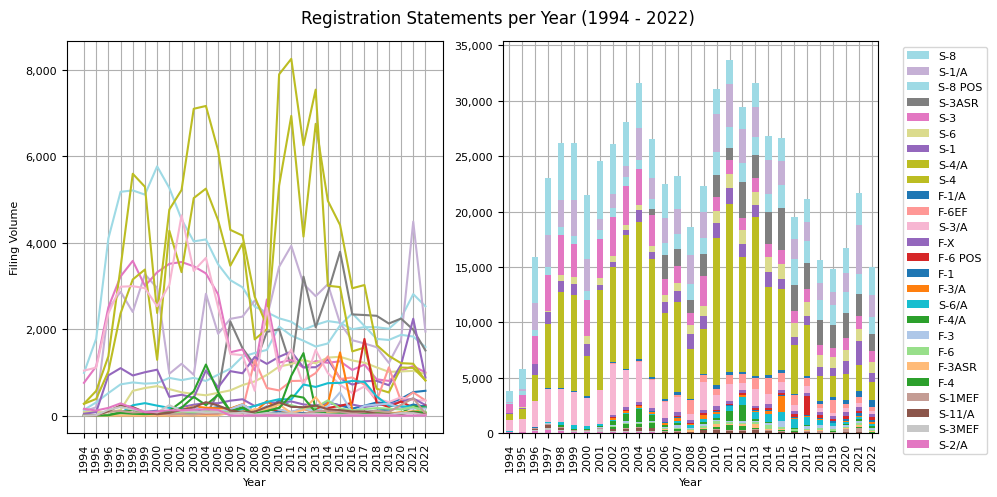

In [ ]:
plot_2_figs(filing_count_stats_reg_year_subset, "Registration Statements per Year (1994 - 2022)", figsize=(10, 5))

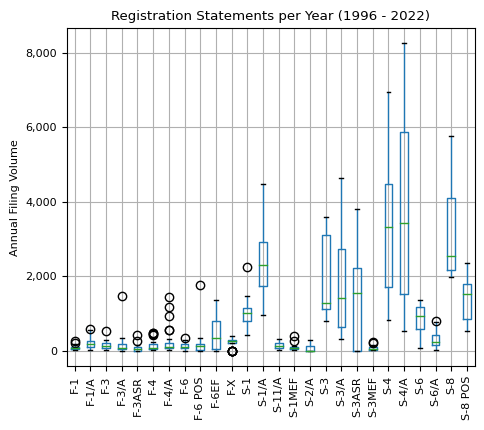

In [ ]:
plot_box_plot(filing_count_stats_reg_year_subset.loc[1996:],
              "Registration Statements per Year (1996 - 2022)", "", "Annual Filing Volume")

In [ ]:
view_s_subset = filing_count_stats_reg_year_subset.columns.str.startswith('S-')
view_f_subset = filing_count_stats_reg_year_subset.columns.str.startswith('F-')

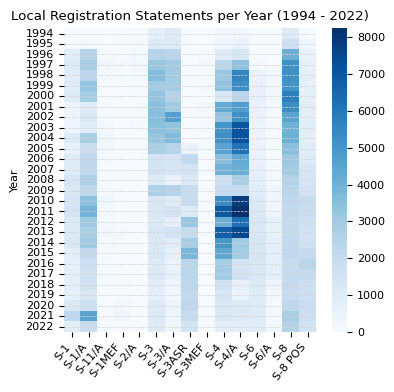

In [ ]:
sns.heatmap(filing_count_stats_reg_year_subset.loc[:, view_s_subset], cmap='Blues')
plt.gcf().set_size_inches(4, 4)
plt.title("Local Registration Statements per Year (1994 - 2022)"), plt.ylabel("Year"), plt.xlabel(""), plt.tight_layout()
plt.gca().yaxis.grid(color='lightgrey', linestyle='dashed', linewidth=0.5)
ax = plt.gca()
ax.tick_params(axis='x', rotation=50), ax.set_xticklabels(ax.get_xticklabels(), ha='right')
plt.show()

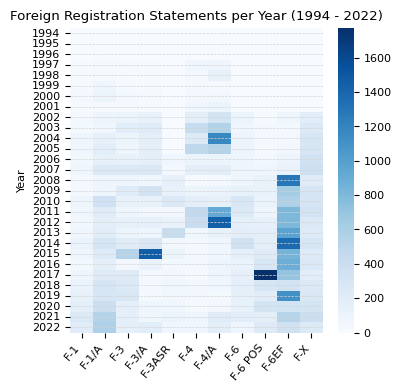

In [ ]:
sns.heatmap(filing_count_stats_reg_year_subset.loc[:, view_f_subset], cmap='Blues')
plt.gcf().set_size_inches(4, 4)
plt.title("Foreign Registration Statements per Year (1994 - 2022)")
plt.ylabel("Year"), plt.xlabel(""), plt.tight_layout()
plt.gca().yaxis.grid(color='lightgrey', linestyle='dashed', linewidth=0.5)
ax = plt.gca()
ax.tick_params(axis='x', rotation=50), ax.set_xticklabels(ax.get_xticklabels(), ha='right')
plt.show()

In [ ]:
filing_count_stats_year = filing_count_stats[['year', 'sector', 'formType', 'count']].groupby(['year', 'sector', 'formType']).sum().reset_index()

In [ ]:
view_s1 = filing_count_stats_year['formType'] == 'S-1'
filing_count_stats_year_piv_s1 = filing_count_stats_year[view_s1].pivot(index='year', columns='sector', values='count')
filing_count_stats_year_piv_s1.fillna(0, inplace=True)

In [ ]:
s1_sums = pd.DataFrame(filing_count_stats_year_piv_s1.sum(axis=1), columns=['sum'])
s1_sums['pct_change'] = s1_sums.pct_change(axis=0) * 100
s1_sums.fillna(0, inplace=True)
s1_sums = s1_sums.astype(int)
s1_sums[-10:]

,sum,pct_change
year,,
2013,533,56
2014,586,9
2015,445,-24
2016,354,-20
2017,477,34
2018,448,-6
2019,455,1
2020,877,92
2021,1452,65


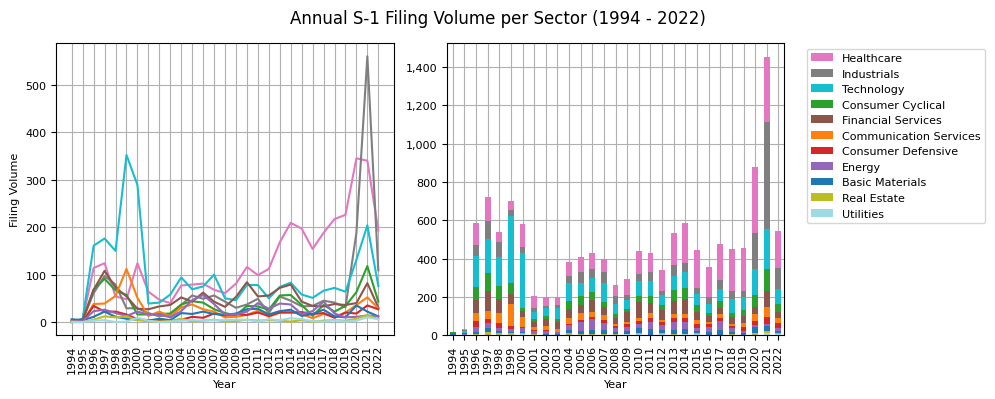

In [ ]:
plot_2_figs(filing_count_stats_year_piv_s1, "Annual S-1 Filing Volume per Sector (1994 - 2022)")

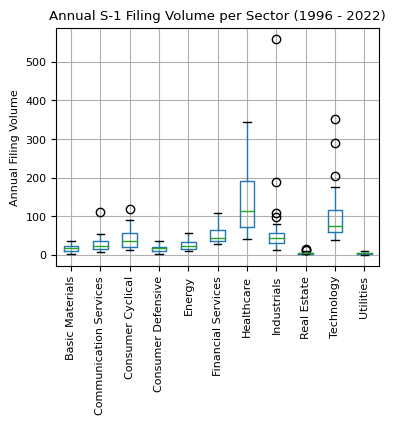

In [ ]:
plot_box_plot(filing_count_stats_year_piv_s1.loc[1996:],
              "Annual S-1 Filing Volume per Sector (1996 - 2022)", "", "Annual Filing Volume", figsize=(4,3))

In [ ]:
view_s1a = filing_count_stats_year['formType'] == 'S-1/A'
filing_count_stats_year_piv_s1a = filing_count_stats_year[view_s1a].pivot(index='year', columns='sector', values='count')
filing_count_stats_year_piv_s1a.fillna(0, inplace=True)

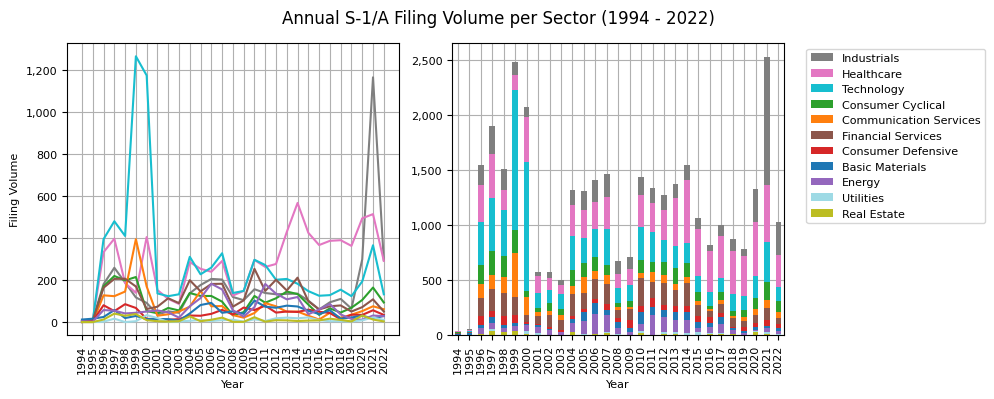

In [ ]:
plot_2_figs(filing_count_stats_year_piv_s1a, "Annual S-1/A Filing Volume per Sector (1994 - 2022)")

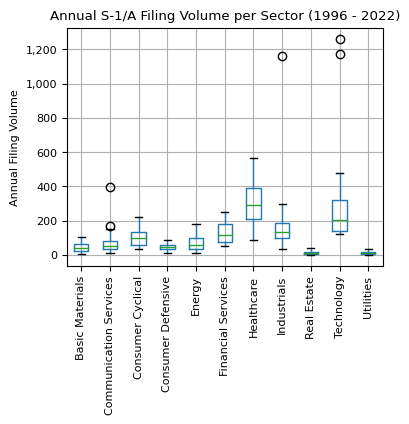

In [ ]:
plot_box_plot(filing_count_stats_year_piv_s1a.loc[1996:],
              "Annual S-1/A Filing Volume per Sector (1996 - 2022)", "", "Annual Filing Volume", figsize=(4,3))

**Observations**:

1. **IPOs**: In 2021, the number of IPOs, as gauged by S-1 filings, reached an unprecedented all-time high with over 1,400 submissions. Remarkably, the combined IPO activity in the Industrials and Healthcare sectors accounted for more than half of all IPOs. This volume even surpassed the flurry seen during the pre-dot-com bubble era, marking the highest since the 2000 bubble.
2. **Healthcare Sector**:
   - The Healthcare sector recorded its most significant growth in S-1 filings between 2008 and 2014, briefly dipped from 2014 to 2016, and then hit a record in 2020 with nearly 350 S-1 filings.
   - The momentum in S-1 filings has been upward since 2008, climaxing in 2020 with over 300 filings.
3. **Tech-Boom**:
   - The late '90s tech boom is evident with a surge in S-1 filings from 1996 to 1999, which saw a more than 100% growth. However, post the 1999 peak of 350 filings, there was a sharp decline to less than 50 by 2001. A significant resurgence occurred between 2019 to 2021, with filings spiking to over 300 in 2021 from a stable base of 70 in 2019. This uptrend was followed by a dip in 2022, dropping below 100.
4. **M&A Activity**:
   - S-4 and S-4/A filing volumes suggest heightened M&A activity during 2003-2004 and 2010-2013, possibly reflecting post-crisis consolidations.
   - Overall, M&A activity, as suggested by these filings, has been on the decline post-2013.
5. **Additional Filings**:
   - 2021 saw a peak in S-1/A filings.
   - F-3/A filings experienced a spike in 2015.
   - F-4/A filings had notable increases in 2004 and 2012.
   - F-6 POS peaked in 2017, while F-6EF had distinct spikes in 2008, 2014, and 2019.
6. **SPAC Trend**: The rise of Special Purpose Acquisition Companies (SPACs) from 2019 to 2021 can be attributed to the Industrials sector.
7. **Post Dot-Com Bubble**: After the dot-com bubble burst, S-1 filings plummeted by 61% from 583 in 2000 to 206 in 2001. While the volume remained flat between 2001 and 2003, there was a significant 92% increase from 2003 to 2004.
8. **Amendments**: The volume of S-1/A filings consistently surpassing S-1 filings underscores the continuous flow of new information post the initial S-1 submission. This highlights the importance of monitoring not just the original S-1 but all subsequent amendments for a comprehensive understanding.

**From S-4 Excursion**

Form S-4 is used for the registration of securities involved in business combinations, such as mergers, consolidations, or transfers of assets. An increase in the number of S-4 filings in a given year can indicate several things:

- **M&A Activity**: A rise in the number of S-4 filings typically points to an increase in merger and acquisition (M&A) activity. More companies might be merging, acquiring others, or undergoing asset transfers.
- **Favorable Market Conditions**: Companies often engage in M&A activities when market conditions are favorable, interest rates are low, and access to capital is easier. An uptick in S-4 filings could signal optimistic market conditions or might reflect optimism about future conditions. Companies might be merging or acquiring in anticipation of future growth.
- **Industry Consolidation**: It could indicate consolidation within specific industries. For example, if a particular sector is undergoing significant changes, companies within that sector might merge to better compete or achieve economies of scale.
- **Tax or Regulatory Changes**: Changes in tax laws or regulations can sometimes motivate companies to engage in M&A activities to optimize their structures or operations in light of the new rules.

**From F-6 POS Excursion**

Form F-6 is used to register American Depositary Receipts (ADRs) issued by a depositary against the deposit of the securities of a foreign issuer. ADRs are a way for U.S. investors to purchase shares of foreign companies without buying the actual shares directly. Instead, they buy the ADRs, which represent shares held in a bank.

The "POS" in "F-6 POS" stands for "Post-Effective Amendment". A Post-Effective Amendment is filed to update, amend, or provide additional information to a previously filed registration statement after it has become effective.

In the context of "F-6 POS," it means that the depositary is amending a previously effective registration statement related to the ADRs. This could be due to various reasons, such as changes in the terms of the ADRs, changes in the underlying agreement, or to provide updated information about the foreign issuer.

---

## Late-Filing Notification Trends

The "NT" in EDGAR filings stands for "Non-Timely." These filings are used when a registrant knows it will not be able to file a required report on time. The "NT" filings allow the registrant to notify the SEC and investors that there will be a delay and provide reasons for the delay. Here are the specific "NT" forms:

- **Form NT 10-K**: This form is filed when a company cannot timely file its annual report, Form 10-K. The company is required to file the Form NT 10-K within one business day after the due date of the 10-K.
- **Form NT 10-Q**: This form is used when a company cannot timely file its quarterly report, Form 10-Q. Similar to the NT 10-K, the company must file the Form NT 10-Q within one business day after the due date of the 10-Q.
- **Form NT 20-F**: This is for foreign private issuers who can't file their annual report on Form 20-F on time.
- **Form NT 11-K**: This is used when the required annual report of employee stock purchase, savings, and similar plans (Form 11-K) cannot be filed on time.
- Other forms: 10-D, N-CEN, N-CSR

When filing an "NT" form, the company typically has to state the reasons for the delay and, in some cases, when it expects to file the report. If the report is not filed within the grace period (typically 15 calendar days for Forms 10-K and 20-F, and 5 calendar days for Form 10-Q), the company can face penalties or other regulatory actions from the SEC.

Potential reasons for a company's filing delay, which could influence its stock price, include:

- **Pending Financial Restatements**: If a company identifies errors in its previously issued financial statements and decides to restate them, it might need additional time to finalize the corrected statements.
- **Litigation or Regulatory Issues**: Pending litigation or regulatory investigations can introduce uncertainties that affect the financial statements. The company might delay its filing until there's more clarity on these matters.
- **Internal Controls Issues**: A company might identify deficiencies or material weaknesses in its internal control over financial reporting. Addressing and documenting these issues can delay the preparation of financial statements.

Possible reasons that are less likely to impact a company's stock price include:

- **Acquisitions or Mergers**: If a company recently underwent a significant merger or acquisition, the complexities of integrating and accounting for the acquired entity could result in delays.
- **Management Turnover**: If key members of the financial or executive team have recently left the company or if there's been significant turnover, the company might face challenges in preparing its financial reports on time.
- **Complex Transactions**: The company might have engaged in complex transactions during the period, such as debt restructuring, which requires additional time to account for and disclose appropriately.
- **External Factors**: Natural disasters, pandemics, or other significant external events might disrupt a company's ability to prepare and finalize its reports.
- **System or Technology Failures**: Technical issues, such as system outages or failures in financial reporting software, can hinder the preparation of financial statements.

In [ ]:
view_nt = filing_count_stats['formType'].str.startswith('NT ')
filing_count_stats_nt = filing_count_stats[view_nt]

In [ ]:
print("Late Filing Types:")
filing_count_stats_nt[filing_count_stats_nt['year'] >= 2000]['formType'].unique()

Late Filing Types:


array(['NT 10-Q', 'NT 10-K', 'NT 11-K', 'NT 10-Q/A', 'NT 10-K/A',
       'NT 20-F', 'NT 11-K/A', 'NT 15D2/A', 'NT 20-F/A', 'NT 15D2',
       'NT 10-D', 'NT 10-D/A'], dtype=object)

In [ ]:
filing_count_stats_nt_year = filing_count_stats_nt[['year', 'formType', 'count']].groupby(['year', 'formType']).sum().reset_index()

In [ ]:
filing_count_stats_nt_year_piv = filing_count_stats_nt_year.pivot(index='year', columns='formType', values='count')
filing_count_stats_nt_year_piv.fillna(0, inplace=True)
filing_count_stats_nt_year_piv = filing_count_stats_nt_year_piv.astype(int)

In [ ]:
filing_count_stats_nt_year_piv_t = filing_count_stats_nt_year_piv.transpose()
filing_count_stats_nt_year_piv_t['avg'] = filing_count_stats_nt_year_piv_t.mean(axis=1)
filing_count_stats_nt_year_piv_t = filing_count_stats_nt_year_piv_t[filing_count_stats_nt_year_piv_t['avg'] > 5]
filing_count_stats_nt_year_piv_t.drop(columns=['avg'], inplace=True)
filing_count_stats_nt_year_piv = filing_count_stats_nt_year_piv_t.transpose()
filing_count_stats_nt_year_piv.index = filing_count_stats_nt_year_piv.index.astype(int)
filing_count_stats_nt_year_piv[-10:]

formType,NT 10-K,NT 10-K/A,NT 10-Q,NT 10-Q/A,NT 11-K,NT 20-F
year,,,,,,
2013,1577,19,2767,12,22,62
2014,1467,8,2553,10,11,64
2015,1389,7,2301,8,27,64
2016,1255,18,2183,9,30,60
2017,1074,17,1874,10,18,62
2018,964,12,1671,7,14,77
2019,874,9,1555,6,3,83
2020,714,25,1068,17,7,72
2021,707,10,1880,22,11,104


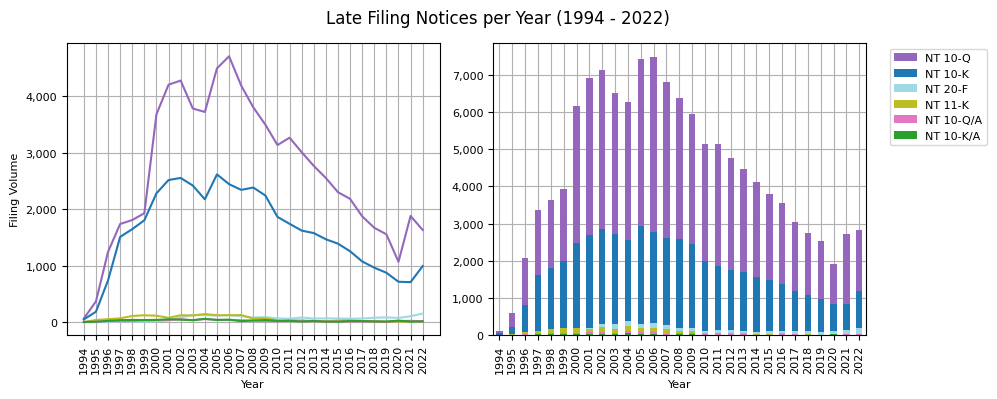

In [ ]:
plot_2_figs(filing_count_stats_nt_year_piv, "Late Filing Notices per Year (1994 - 2022)")

In [ ]:
view_nt_10q = filing_count_stats_year['formType'] == 'NT 10-Q'
filing_count_stats_year_piv_nt = filing_count_stats_year[view_nt_10q].pivot(index='year', columns='sector', values='count')
filing_count_stats_year_piv_nt[-5:]

sector,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Utilities
year,,,,,,,,,,,
2018,20.0,39.0,44.0,25.0,24.0,27.0,93.0,78.0,13.0,89.0,3.0
2019,25.0,29.0,45.0,26.0,33.0,22.0,108.0,92.0,15.0,71.0,4.0
2020,13.0,20.0,45.0,18.0,32.0,25.0,74.0,60.0,10.0,47.0,3.0
2021,24.0,41.0,59.0,24.0,15.0,32.0,131.0,537.0,12.0,106.0,9.0
2022,16.0,25.0,39.0,21.0,16.0,40.0,104.0,320.0,7.0,91.0,4.0


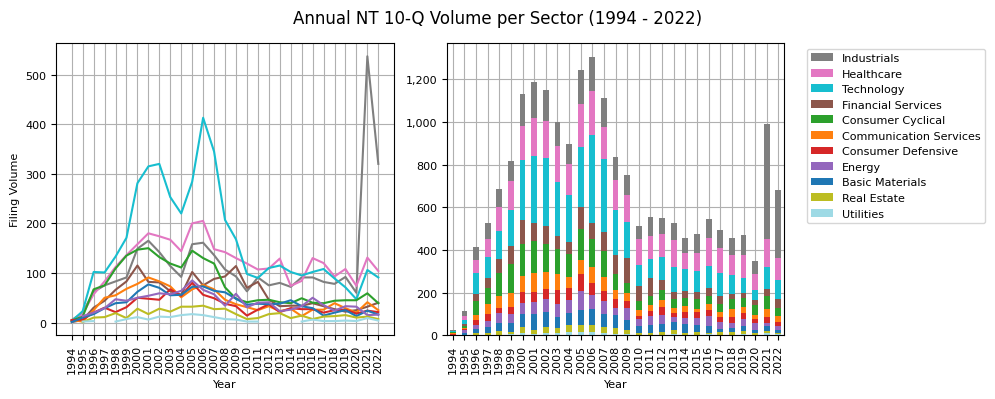

In [ ]:
plot_2_figs(filing_count_stats_year_piv_nt,  "Annual NT 10-Q Volume per Sector (1994 - 2022)")

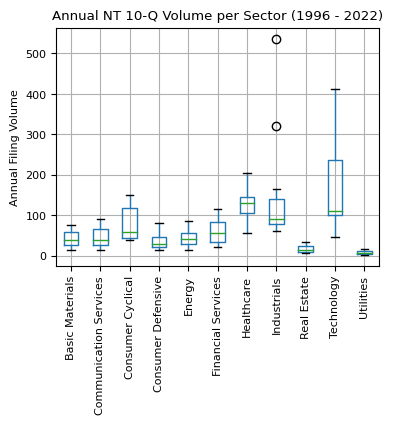

In [ ]:
plot_box_plot(filing_count_stats_year_piv_nt.loc[1996:],
              "Annual NT 10-Q Volume per Sector (1996 - 2022)", "", "Annual Filing Volume", figsize=(4, 3))

**Observations**:

- **NT Filing Trends**:
   - The peak annual volume for NT filings occurred in 2006 with 7,500 filings, closely followed by 2002 which registered just over 7,000 filings.
   - A consistent decline in NT filings was observed post-2006, reaching a record low of under 2,000 filings in 2020. However, this trend saw a reversal in 2021 and 2022.
- **Composition of NT Filings**: NT 10-Q and NT 10-K submissions constitute approximately 95% of all NT filings from 1994 to 2022.
- **Sectoral Indicators**:
   - In the lead-up to the dot-com bubble and the subsequent financial crisis, the Technology sector dominated NT 10-Q filings, serving as a potential early indicator of market turbulence.
   - A similar pattern was evident in the Industrials sector (notably driven by SPACs), which saw a jump from 70 filings in 2020 to over 500 in 2021. Notably, other sectors remained stable during this period.
- **Historical Highs**: The Industrials sector's NT filings reached an all-time high in 2021, surpassing even the volumes seen during the dot-com and financial crises and outpacing the Technology sector's 2006 figures.
- **Sectoral Medians**: Over the period from 1994 to 2022, the Healthcare and Tech sectors recorded the highest median annual NT volumes.
- **Sectoral Variability**: Utilities and Real Estate sectors displayed the least variability in their NT filings, indicating more consistent filing behavior.

---

## Delisting Notification Trends - 25-NSE Filings

When a publicly traded company doesn't meet the $1 share price minimum or other listing requirements of a stock exchange, the exchange itself will file a **Form 25** on EDGAR. Form 25 is the "Notification of Removal from Listing and/or Registration" and is used by the national securities exchanges to delist and deregister a security.

The process usually goes as follows:

1. The exchange notifies the company that it is out of compliance with listing standards.
2. The company is given a grace period to regain compliance.
3. If the company fails to regain compliance within that period, the exchange may decide to delist the security.
4. The exchange will then file a Form 25 to initiate the delisting and deregistration process.

It's worth noting that while Form 25 is the primary notification of delisting, it's the final step in a longer compliance process. Previous filings, such as Form 8-Ks, might have indicated potential compliance issues. In a Form 8-K filing, Item 3.01, titled "Notice of Delisting or Failure to Satisfy a Continued Listing Rule or Standard; Transfer of Listing," requires public companies to disclose any notifications received from an exchange indicating the company's non-compliance with listing standards.

In [ ]:
view_25_nse = filing_count_stats['formType'].str.startswith('25-NSE')
filing_count_stats_25_nse = filing_count_stats[view_25_nse]

In [ ]:
print("25-NSE Form Types:")
filing_count_stats_25_nse[filing_count_stats_25_nse['year'] >= 2000]['formType'].unique()

25-NSE Form Types:


array(['25-NSE', '25-NSE/A'], dtype=object)

In [ ]:
filing_count_stats_25_nse_year = filing_count_stats_25_nse[['year', 'formType', 'count']].groupby(['year', 'formType']).sum().reset_index()

In [ ]:
filing_count_stats_25_nse_year_piv = filing_count_stats_25_nse_year.pivot(index='year', columns='formType', values='count')
filing_count_stats_25_nse_year_piv.fillna(0, inplace=True)
filing_count_stats_25_nse_year_piv = filing_count_stats_25_nse_year_piv.astype(int)
filing_count_stats_25_nse_year_piv[-5:]

formType,25-NSE,25-NSE/A
year,,
2018,1650,8
2019,1612,44
2020,1794,14
2021,2026,26
2022,1970,18


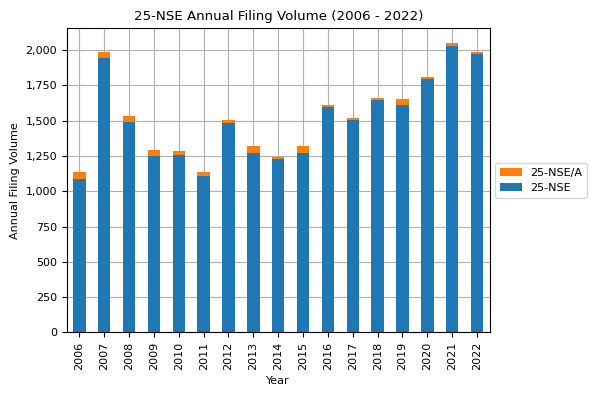

In [ ]:
filing_count_stats_25_nse_year_piv.plot(kind='bar', stacked=True, figsize=(5, 4))
plt.title("25-NSE Annual Filing Volume (2006 - 2022)")
plt.ylabel("Annual Filing Volume"), plt.xlabel("Year"), plt.tight_layout()
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(), ax.set_axisbelow(True)
plt.show()

In [ ]:
view_25_nse = filing_count_stats_year['formType'] == '25-NSE'
filing_count_stats_year_piv_nse = filing_count_stats_year[view_25_nse].pivot(index='year', columns='sector', values='count')
filing_count_stats_year_piv_nse[-5:]

sector,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Utilities
year,,,,,,,,,,,
2018,27,27,29,21,60,126,63,47,39,55,12
2019,28,22,46,23,59,90,70,60,38,70,9
2020,16,41,53,32,52,145,77,59,23,36,15
2021,23,39,63,29,42,181,97,70,71,84,17
2022,28,22,25,30,29,96,92,269,27,75,16


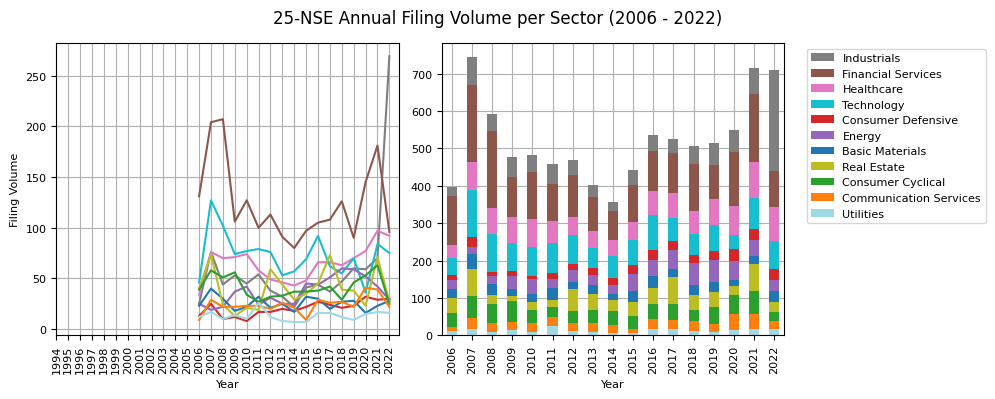

In [ ]:
plot_2_figs(filing_count_stats_year_piv_nse, "25-NSE Annual Filing Volume per Sector (2006 - 2022)")

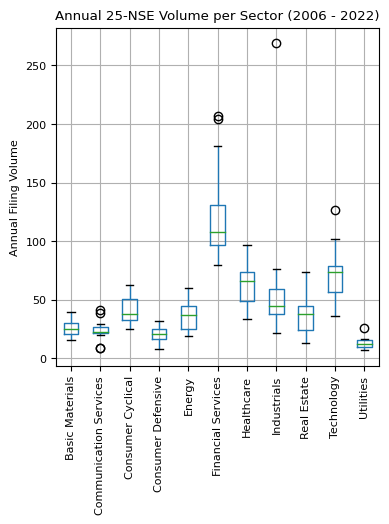

In [ ]:
plot_box_plot(filing_count_stats_year_piv_nse,
              "Annual 25-NSE Volume per Sector (2006 - 2022)", "", "Annual Filing Volume", figsize=(4, 4))

**Observations**:

- **Trends in 25-NSE Filings**:
   - The annual volume of 25-NSE filings has consistently risen from 2011 through 2022.
   - 2021 marked the record year for delistings with 2,026 instances, closely followed by 2022 with 1,970 cases and 2007 with 1,944.
   - Interestingly, there was a continuous decrease from 2007 to 2010 in the wake of the financial crisis. This post-crisis period, especially 2007, saw accelerated market corrections, as indicated by the high delisting volumes.
- **Sectoral Highlights**:
   - The Industrials sector, potentially reflective of SPAC activities, registered the highest number of delistings in 2022, with over 250 25-NSE filings.
   - The Financial Services sector has historically been a major recipient of 25-NSE filings, witnessing a peak in 2007/2008 with over 200 filings. After reaching a low in 2014, the sector experienced its second-highest volume in 2021 with 170 filings.
   - The Technology sector ranks second in terms of delisting numbers, maintaining a median annual figure of around 70 delistings.
- **Sectoral Lows**:
   - From 2006 to 2022, sectors such as Utilities, Communications Services, Consumer Defensive, and Basic Materials consistently recorded the fewest annual delistings.

---

## Insider Trading Filing Trends

SEC Forms 3, 4, and 5 are designed to provide transparency regarding the transactions of company insiders in their own company's stock. "Insiders" are defined as officers, directors, and beneficial owners holding more than 10% of a class of the company's equity securities. In essence, these forms aim to provide transparency and prevent illegal insider trading by ensuring that the public has timely access to information about transactions by company insiders.

- **Form 3 - Initial Statement of Beneficial Ownership**: This form is used by insiders to report their initial ownership of the company's securities when they first become an insider. Insiders must file Form 3 within ten days of becoming an officer, director, or beneficial owner.

- **Form 4 - Statement of Changes in Beneficial Ownership**: This form is used by insiders to report changes in their ownership, such as purchases, sales, gifts, or other acquisitions or dispositions of the company's securities. Form 4 must be filed within two business days following the day on which the transaction occurred.

- **Form 5 - Annual Statement of Beneficial Ownership**: This form is used by insiders to report any transactions that should have been reported earlier on a Form 4 or were eligible for deferred reporting. It's also used to report transactions that are exempt from immediate reporting requirements, such as those under employee benefit plans. Form 5 must be filed within 45 days after the company's fiscal year-end. If there are no unreported transactions, the insider does not need to file a Form 5.



In [ ]:
view_3_insider = (filing_count_stats['formType']=='3') | (filing_count_stats['formType']=='3/A')
view_4_insider = (filing_count_stats['formType']=='4') | (filing_count_stats['formType']=='4/A')
view_5_insider = (filing_count_stats['formType']=='5') | (filing_count_stats['formType']=='5/A')

In [ ]:
insider_stats = filing_count_stats[view_3_insider | view_4_insider | view_5_insider]
insider_4_stats = filing_count_stats[view_4_insider]

In [ ]:
insider_4_stats_year = insider_4_stats[['year', 'sector', 'count']].groupby(['year', 'sector'], dropna=False).sum().reset_index()

In [ ]:
insider_4_stats_year_piv = insider_4_stats_year.pivot(index='year', columns='sector', values='count')
insider_4_stats_year_piv.fillna(0, inplace=True)
insider_4_stats_year_piv = insider_4_stats_year_piv.astype(int)
insider_4_stats_year_piv[-10:]

sector,NaN,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Utilities
year,,,,,,,,,,,,
2013,223494,10288,9180,21570,9264,11006,32734,23886,23321,7560,32105,5796
2014,222278,10139,8469,21345,9362,11790,32785,26436,22794,8499,30752,5837
2015,221462,9535,8790,21427,9132,10670,33391,27468,21797,8796,30358,5798
2016,210806,9033,8584,20590,8072,9977,33302,26133,21179,8853,27610,5284
2017,207690,9629,8145,20263,7946,9416,32954,26188,21108,8835,27873,4679
2018,206174,9042,8642,19557,7768,9255,31701,27719,23732,8983,26174,4311
2019,199608,8433,7802,18799,7381,8350,30479,29031,22644,8764,27127,4229
2020,206279,8434,8327,18465,7870,7220,32612,33103,21177,8978,27915,3870
2021,225712,8649,8742,21371,8219,7527,32392,37087,22818,9057,31457,3844


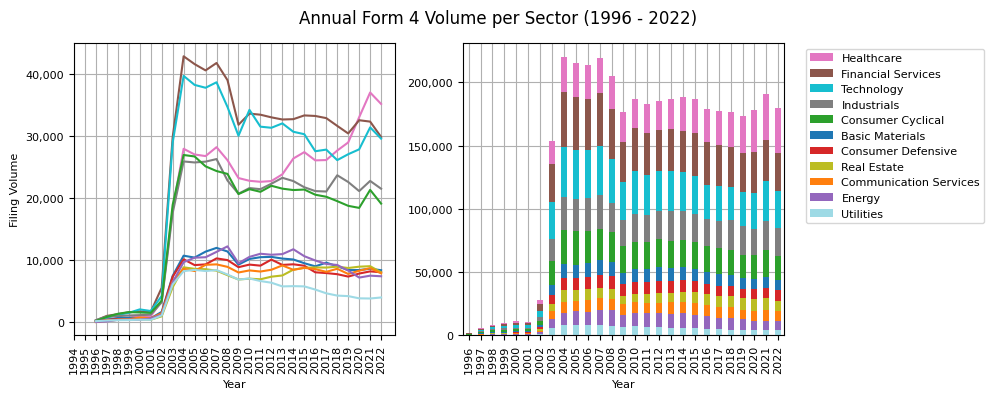

In [ ]:
plot_2_figs(insider_4_stats_year_piv.drop(columns=[np.nan]), "Annual Form 4 Volume per Sector (1996 - 2022)")

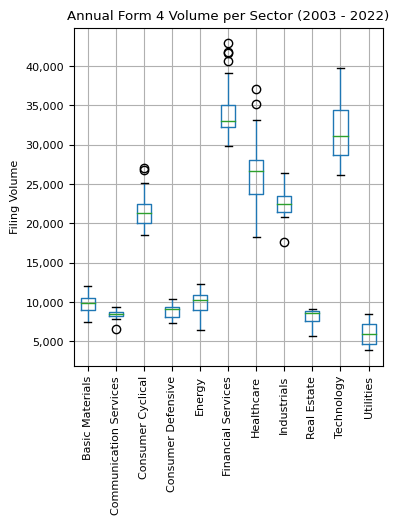

In [ ]:
plot_box_plot(insider_4_stats_year_piv.loc[2003:].drop(columns=[np.nan]),
              "Annual Form 4 Volume per Sector (2003 - 2022)", "", "Filing Volume", figsize=(4, 4))

In [ ]:
form_4_2022 = pd.DataFrame(insider_4_stats_year_piv.loc[2022]).sort_values(by=2022, ascending=False)
form_4_2022['pct'] = form_4_2022[2022] / form_4_2022[2022].sum() * 100
form_4_2022 = form_4_2022.round(1)
form_4_2022

,2022,pct
sector,,
NaN,208892,53.8
Healthcare,35239,9.1
Financial Services,29907,7.7
Technology,29639,7.6
Industrials,21560,5.6
Consumer Cyclical,19156,4.9
Basic Materials,8407,2.2
Consumer Defensive,8081,2.1
Real Estate,8057,2.1


**Observations**:

- **Peak in Insider Trading Filings**: A majority of sectors (10 out of 11) experienced their highest volume of insider trading filings (Form 4) in 2004, with a subsequent decline observed in the ensuing years.
- **Healthcare Sector Trend**: Contrary to the general trend, the Healthcare sector has witnessed a continuous rise in Form 4 filing volume since 2012. Remarkably, in 2021, its filing volume almost matched the peak observed in the Technology sector in 2004.
- **Leading Sectors in 2022**: The sectors with the highest number of Form 4 filings in 2022 were, in descending order: Healthcare, Finance, Technology, Industrials, and Consumer Cyclical.
- **Unassigned Entities**: Notably, over half (53%) of the entities mentioned in Form 4 filings in 2022 did not have a designated sector. While not all entities have a specific sector assigned to them, the companies in which the securities transactions are taking place usually have an associated sector.

The lack of sector assignment can be attributed to various factors:

**Nature of the Entity**: The entities can be diverse, including trusts, limited partnerships, investment vehicles, or other types of organizational structures. These entities might not operate in a specific sector but rather serve a specific purpose, such as estate planning or investment.

**Lack of Public Information**: Many of the entities might not be public entities. Without public filings, there might be limited information available about the primary sector of the entity.

**Diverse Investments**: Some entities, especially investment vehicles, might have a diverse portfolio of investments spanning multiple sectors. Assigning them to a specific sector would be inaccurate or overly simplistic.




## 8-K Filing Trends

Form 8-K is known as a "Current Report" and is filed with the SEC by publicly traded companies. The primary purpose of Form 8-K is to inform the public and the SEC of significant corporate events. This form is distinct from the periodic reports that companies are obligated to file (e.g. quarterly 10-Qs and annual 10-Ks) and is triggered by specific events.

Here are some of the key events that might trigger an 8-K filing:

1. **Entry into or Termination of a Material Agreement**: Major contract or the termination of such an agreement.
2. **Completion of Acquisition or Disposition of Assets**: Significant acquisitions or sales of assets.
3. **Changes in Management**: Appointments, resignations, or departures of directors or certain officers.
4. **Changes in Financial Condition**: Bankruptcy, receivership, or any financial difficulties.
5. **Other Events**: Stock splits, amendments to the company's articles of incorporation or bylaws, or changes to the company's fiscal year.
6. **Notices of Delisting or Failure to Satisfy Listing Standards**: If a company receives a warning from a stock exchange about potential delisting due to non-compliance with listing standards, it would file an 8-K.
7. **Material Modifications to Rights of Security Holders**: Changes that might affect the rights of shareholders or other security holders.
8. **Results of Shareholder Votes**: The outcome of significant shareholder votes during meetings.

In [ ]:
view_8k = filing_count_stats['formType'] == '8-K'
view_8ka = filing_count_stats['formType'] == '8-K/A'
stats_8k = filing_count_stats[view_8k | view_8ka]

In [ ]:
count_8k = stats_8k[['year', 'formType', 'count']].groupby(['year', 'formType']).sum().reset_index()
count_8k_piv = count_8k.pivot(index='year', columns='formType', values='count')

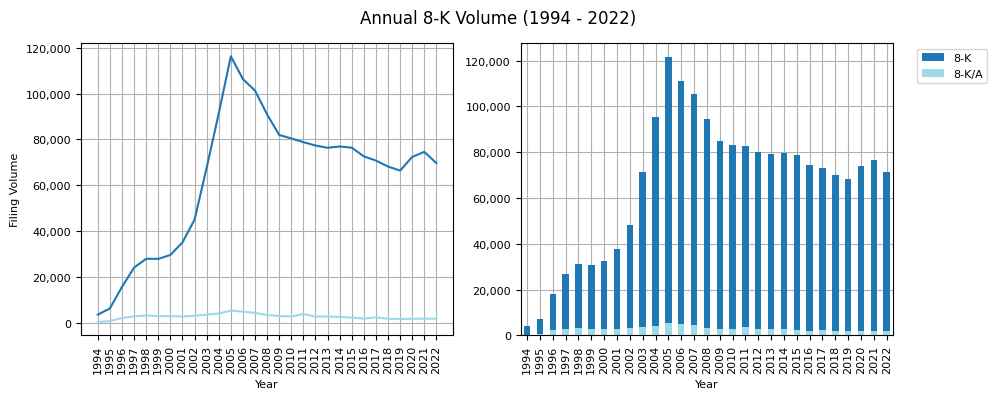

In [ ]:
plot_2_figs(count_8k_piv, "Annual 8-K Volume (1994 - 2022)")

In [ ]:
count_8k_sector = stats_8k[['year', 'sector', 'count']].groupby(['year', 'sector']).sum().reset_index()
count_8k_sector_piv = count_8k_sector.pivot(index='year', columns='sector', values='count')

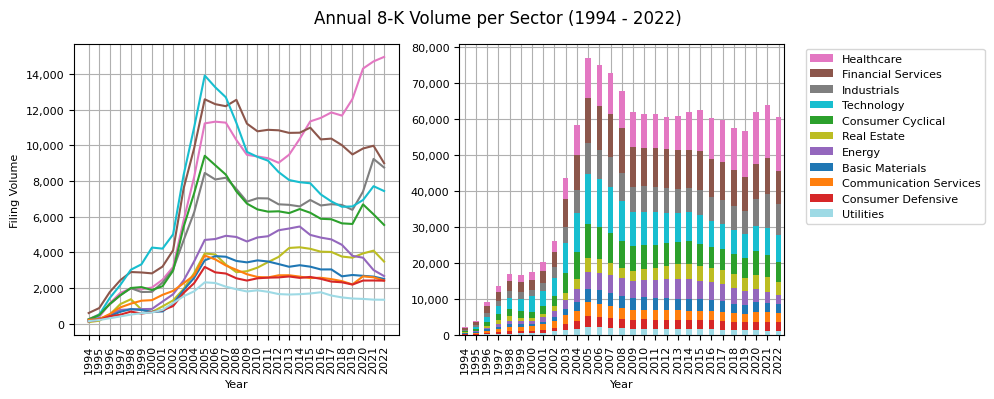

In [ ]:
plot_2_figs(count_8k_sector_piv, "Annual 8-K Volume per Sector (1994 - 2022)")

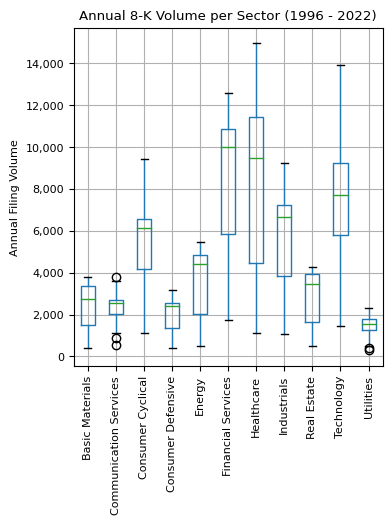

In [ ]:
plot_box_plot(count_8k_sector_piv.loc[1996:],
              "Annual 8-K Volume per Sector (1996 - 2022)", "", "Annual Filing Volume", figsize=(4,4))

**Observations**:

- **Trend in 8-K Filings**:
   - The highest volume of 8-K filings was observed in 2005 with over 120,000 filings. Subsequently, there was a decline, with a slight uptick between 2019 and 2021, reaching just under 80,000 filings in 2021.
   - This downward trend could suggest companies are becoming more selective in their disclosures or that fewer events are deemed significant enough for disclosure. However, considering the increased interconnectivity in the digital age, it seems counterintuitive that there would be fewer events of note since 2005.
- **Sectoral Insights**:
   - The Healthcare sector has seen a consistent rise in 8-K filings since 2012, reaching an all-time high of 15,000 filings in 2022.
   - In 2005, the Tech and Financial Services sectors led in 8-K filings, with Financial Services maintaining its position as the second-largest contributor in 2022, while Tech dropped to fourth place.
   - The COVID pandemic appeared to have a minimal effect on 8-K filing volumes, with only slight increases noted in the Financial Services, Tech, and Consumer Cyclical sectors.
   - The Industrials sector witnessed a notable increase in filings from 6,000 to over 9,000 between 2019 and 2021.
- **Potential Indicator of Volatility**: The volume of 8-K filings per sector may serve as an indicator of annual volatility within those sectors. A higher frequency of 8-K filings might suggest greater sector volatility, as significant events that warrant disclosure could influence stock prices. Conversely, sectors with fewer 8-K filings might be associated with lower volatility.
- **Sectors with Stable 8-K Filing Volumes**: Utilities, Consumer Defensive, Communications Services, Basic Materials, Real Estate, and Energy sectors have exhibited stable annual 8-K filing volumes.